exclude predefined participants
mark invalid trials (NaN) for incorrect RTs, RT < 150, TFF < 100, trimmed TFF
compute the RT pool from the remaining finite RTs
calculate the global upper winsor bound
cap RTs above that bound
only then create the final valid-trial dataset

Great! Since your Experiment 1 code is now finalized and logically sound, you can move forward with running it.

To help you hit the ground running with your **Methods and Results** sections, here is a quick guide on how to report the "Audit" and "Summary" data generated by this script:

### 1. The "Data Funnel" (Results Section)

Your `Exp1_step_summary_sequential.csv` is designed to be your primary "Table 1." When you write about it, you can say:

> "Of the initial [X] trials possible across the 59 included participants, data were filtered sequentially. [N] trials were excluded due to premature fixation (TFF < 100 ms), followed by [N] trials removed via session-wise TFF trimming (±2 SD). Behavioral errors accounted for [N] exclusions, and anticipatory responses (RT < 150 ms) for [N] trials. This resulted in a final analytic sample of [N] trials (Retention Rate: [X]%)."

### 2. The Accuracy Defense

Because you are using only the manual exclusion file, your supervisor might ask about participant performance. You can use your `Exp1_summary_TFF.csv` to point out:

* The **Mean Accuracy** of the survivors (which we calculated earlier to be high).
* That even though you kept participants with lower overall performance, **every single trial** in the final analysis is $100\%$ correct because errors were set to NaN in Step 3.

### 3. Log Transformation & Winsorization

In your Methods, you should mention:

* **Winsorization:** "To manage the right-skewed distribution of reaction times, a global upper-tail Winsorization was applied at 2.0 standard deviations above the mean."
* **Normality:** "Both RT and TFF data were log-transformed ($log_{10}$) to meet the normality assumptions of the mixed-effects models."



In [1]:
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def load_csv(name, dtype=float):
    df = pd.read_csv(name, header=None)
    return df.to_numpy(dtype=dtype)

def convert_rt_to_ms(rt):
    """
    Convert RT from sec to ms if data look like seconds.
    """
    rt = np.asarray(rt, dtype=float)
    med = np.nanmedian(rt)
    if 0.05 <= med <= 5.0:
        return rt * 1000.0, "sec→ms"
    return rt.copy(), "ms"

def merge_sessions(arr):
    """
    Merge every 2 columns into one participant vector.
    Assumes 2 sessions per participant.
    """
    trials, cols = arr.shape
    assert cols % 2 == 0, "Expected even number of columns."
    merged = []
    for p in range(cols // 2):
        merged.append(np.concatenate([arr[:, 2*p], arr[:, 2*p + 1]]))
    return merged

def get_intended_trial_mask(total_slots, expected_trials, session_storage_len=48):
    """
    For 96-trial participants: all 96 slots intended.
    For 80-trial participants: 40 intended trials in each 48-slot session.
    """
    if expected_trials == 96:
        return np.ones(total_slots, dtype=bool)

    if expected_trials == 80 and total_slots == 96:
        intended_per_session = 40
        s1 = np.r_[
            np.ones(intended_per_session, dtype=bool),
            np.zeros(session_storage_len - intended_per_session, dtype=bool)
        ]
        s2 = np.r_[
            np.ones(intended_per_session, dtype=bool),
            np.zeros(session_storage_len - intended_per_session, dtype=bool)
        ]
        return np.concatenate([s1, s2])

    raise ValueError(
        f"Unsupported combination total_slots={total_slots}, expected_trials={expected_trials}"
    )

def trim_sd_with_flags(x, sd=2):
    """
    Trim values outside mean ± sd*SD by setting them to NaN.
    """
    x = np.asarray(x, dtype=float)
    out = x.copy()
    flag = np.zeros(len(x), dtype=bool)

    valid = np.isfinite(x)
    if valid.sum() < 3:
        return out, flag, np.nan, np.nan

    m = np.nanmean(x[valid])
    s = np.nanstd(x[valid], ddof=1)
    lo, hi = m - sd * s, m + sd * s

    bad = np.isfinite(out) & ((out < lo) | (out > hi))
    flag[bad] = True
    out[bad] = np.nan
    return out, flag, lo, hi

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------

RT_MIN = 150
TFF_MIN = 100
TFF_TRIM_SD = 2
RT_WINSOR_SD = 2

# exclusions from subjectstoremove file
participants_to_exclude = [33, 35, 37, 54, 57, 58]

# reduced-trial participants in Exp1
# first 3 and last 5 participants completed 80 trials
PARTICIPANTS_80_TRIALS = [1, 2, 3, 61, 62, 63, 64, 65]

DEFAULT_EXPECTED_TRIALS = 96
REDUCED_EXPECTED_TRIALS = 80

# ------------------------------------------------------------
# Load raw data
# ------------------------------------------------------------

print("Loading datasets...")

rt_raw       = load_csv("reactionTime.csv")
side_raw     = load_csv("frameSide.csv")
valence_raw  = load_csv("valence.csv")
tff_raw      = load_csv("timeFirstFixation.csv")
reaction_raw = load_csv("actualReaction.csv", dtype=str)
frame_raw    = load_csv("frameColor.csv")

print("rt_raw shape:", rt_raw.shape)
print("tff_raw shape:", tff_raw.shape)
print("Participants to exclude:", participants_to_exclude)

# ------------------------------------------------------------
# Merge sessions
# ------------------------------------------------------------

rt_parts    = merge_sessions(rt_raw)
side_parts  = merge_sessions(side_raw)
val_parts   = merge_sessions(valence_raw)
tff_parts   = merge_sessions(tff_raw)
react_parts = merge_sessions(reaction_raw)
frame_parts = merge_sessions(frame_raw)

n_participants = len(rt_parts)
print(f"Number of merged participants: {n_participants}")

# ------------------------------------------------------------
# First pass:
# apply all rules except RT winsorisation
# collect RTs to compute GLOBAL upper cap
# ------------------------------------------------------------

participant_temp = []
rt_pool_for_global = []

for pid in range(1, n_participants + 1):

    if pid in participants_to_exclude:
        continue

    i = pid - 1

    expected_trials = (
        REDUCED_EXPECTED_TRIALS if pid in PARTICIPANTS_80_TRIALS else DEFAULT_EXPECTED_TRIALS
    )

    rt_raw_part = rt_parts[i].astype(float)
    side = side_parts[i]
    val = val_parts[i]
    tff_raw_part = tff_parts[i].astype(float)
    action = np.char.lower(np.char.strip(react_parts[i].astype(str)))
    frame = frame_parts[i].astype(float)

    intended_mask = get_intended_trial_mask(
        total_slots=len(rt_raw_part),
        expected_trials=expected_trials,
        session_storage_len=48
    )

    # Step 1: TFF < 100 ms -> NaN
    tff_lt100_flag = intended_mask & np.isfinite(tff_raw_part) & (tff_raw_part < TFF_MIN)
    tff_after_min = tff_raw_part.copy()
    tff_after_min[tff_lt100_flag] = np.nan

    # RT convert
    rt_s1, rt_s2 = rt_raw_part[:48], rt_raw_part[48:]
    rt_ms_s1, unit1 = convert_rt_to_ms(rt_s1)
    rt_ms_s2, unit2 = convert_rt_to_ms(rt_s2)
    rt_ms = np.concatenate([rt_ms_s1, rt_ms_s2])

    # Step 2: TFF trim per session
    tff_s1 = tff_after_min[:48]
    tff_s2 = tff_after_min[48:]

    tff_s1_trim, trim_flag_s1, _, _ = trim_sd_with_flags(tff_s1, sd=TFF_TRIM_SD)
    tff_s2_trim, trim_flag_s2, _, _ = trim_sd_with_flags(tff_s2, sd=TFF_TRIM_SD)

    tff_clean_pre = np.concatenate([tff_s1_trim, tff_s2_trim])
    tff_trim_flag = intended_mask & np.concatenate([trim_flag_s1, trim_flag_s2])

    # Step 3: incorrect trial -> RT NaN
    required_action = np.full(len(frame), np.nan, dtype=object)
    required_action[np.isfinite(frame) & (frame == 1)] = "pull"
    required_action[np.isfinite(frame) & (frame == 0)] = "push"

    valid_response_flag = np.isin(action, ["pull", "push"])

    correct_response_flag = (
        intended_mask
        & np.isfinite(frame)
        & valid_response_flag
        & (action == required_action)
    )

    incorrect_rt_flag = (
        intended_mask
        & np.isfinite(frame)
        & valid_response_flag
        & (~correct_response_flag)
    )

    rt_after_accuracy = rt_ms.copy()
    rt_after_accuracy[incorrect_rt_flag] = np.nan

    # Step 4: RT < 150 -> NaN
    rt_too_fast_flag = intended_mask & np.isfinite(rt_after_accuracy) & (rt_after_accuracy < RT_MIN)
    rt_bounded = rt_after_accuracy.copy()
    rt_bounded[rt_too_fast_flag] = np.nan

    # pool for GLOBAL winsor upper bound
    keep_for_pool = intended_mask & np.isfinite(rt_bounded)
    rt_pool_for_global.extend(rt_bounded[keep_for_pool].tolist())

    participant_temp.append({
        "pid": pid,
        "expected_trials": expected_trials,
        "rt_raw_part": rt_raw_part,
        "rt_ms": rt_ms,
        "side": side,
        "val": val,
        "tff_raw_part": tff_raw_part,
        "tff_after_min": tff_after_min,
        "tff_clean_pre": tff_clean_pre,
        "action": action,
        "frame": frame,
        "intended_mask": intended_mask,
        "tff_lt100_flag": tff_lt100_flag,
        "tff_trim_flag": tff_trim_flag,
        "incorrect_rt_flag": incorrect_rt_flag,
        "rt_after_accuracy": rt_after_accuracy,
        "rt_too_fast_flag": rt_too_fast_flag,
        "rt_bounded": rt_bounded
    })

# ------------------------------------------------------------
# Global RT winsor upper bound
# ------------------------------------------------------------

rt_pool_for_global = np.asarray(rt_pool_for_global, dtype=float)

global_rt_mean = np.nanmean(rt_pool_for_global)
global_rt_sd   = np.nanstd(rt_pool_for_global, ddof=1)
global_rt_upper = global_rt_mean + RT_WINSOR_SD * global_rt_sd

print("\nGLOBAL RT winsorisation bound:")
print(f"Mean RT = {global_rt_mean:.3f} ms")
print(f"SD RT   = {global_rt_sd:.3f} ms")
print(f"Upper cap (mean + {RT_WINSOR_SD} SD) = {global_rt_upper:.3f} ms")

# ------------------------------------------------------------
# Second pass:
# apply global winsorisation, build outputs
# ------------------------------------------------------------

rows_clean = []
rows_audit = []
summary = []
expected_trials_all = []
rt_postwinsor_pool = []

for temp in participant_temp:
    pid = temp["pid"]
    expected_trials = temp["expected_trials"]
    expected_trials_all.append(expected_trials)

    rt_raw_part = temp["rt_raw_part"]
    rt_ms = temp["rt_ms"]
    side = temp["side"]
    val = temp["val"]
    tff_raw_part = temp["tff_raw_part"]
    tff_after_min = temp["tff_after_min"]
    tff_clean = temp["tff_clean_pre"]
    action = temp["action"]
    frame = temp["frame"]
    intended_mask = temp["intended_mask"]
    tff_lt100_flag = temp["tff_lt100_flag"]
    tff_trim_flag = temp["tff_trim_flag"]
    incorrect_rt_flag = temp["incorrect_rt_flag"]
    rt_after_accuracy = temp["rt_after_accuracy"]
    rt_too_fast_flag = temp["rt_too_fast_flag"]
    rt_bounded = temp["rt_bounded"]

    # Step 5: global winsorisation upper tail only
    rt_winsor_flag = intended_mask & np.isfinite(rt_bounded) & (rt_bounded > global_rt_upper)
    rt_clean = rt_bounded.copy()
    rt_clean[rt_winsor_flag] = global_rt_upper

    # final valid trials
    valid = intended_mask & np.isfinite(rt_clean) & np.isfinite(tff_clean) & np.isfinite(val)

    # collect post-winsor RTs
    rt_postwinsor_pool.extend(rt_clean[intended_mask & np.isfinite(rt_clean)].tolist())

    # labels
    matrix_slots = np.arange(1, len(rt_raw_part) + 1)
    session_labels = np.where(matrix_slots <= 48, 1, 2)

    intended_trial_numbers = np.full(len(rt_raw_part), np.nan)
    intended_trial_numbers[intended_mask] = np.arange(1, expected_trials + 1)

    side_lbl = pd.Series(side).map({1: "right", 0: "left"}).to_numpy()
    val_lbl = pd.Series(val).map({1: "positive", 0: "negative"}).to_numpy()
    frame_lbl = pd.Series(frame).map({1: "blue_pull", 0: "orange_push"}).to_numpy()

    cond_lbl = pd.Series(np.nan, index=np.arange(len(val)), dtype=object)
    valid_cond = intended_mask & np.isin(action, ["pull", "push"]) & np.isfinite(val)

    cond_lbl.loc[valid_cond] = np.where(
        ((action[valid_cond] == "pull") & (val[valid_cond] == 1)) |
        ((action[valid_cond] == "push") & (val[valid_cond] == 0)),
        "congruent",
        "incongruent"
    )
    cond_lbl = cond_lbl.to_numpy()

    logRT = np.log10(rt_clean)
    logTFF = np.log10(tff_clean)

    intended_positions = np.where(intended_mask)[0]

    for t in intended_positions:
        session = int(session_labels[t])
        intended_trial = int(intended_trial_numbers[t])

        removed = False
        removal_step = ""
        removal_reason = ""

        if tff_lt100_flag[t]:
            removed = True
            removal_step = "Step 1"
            removal_reason = f"TFF < {TFF_MIN} ms"

        elif tff_trim_flag[t]:
            removed = True
            removal_step = "Step 2"
            removal_reason = f"TFF outside session mean ± {TFF_TRIM_SD} SD"

        elif incorrect_rt_flag[t]:
            removed = True
            removal_step = "Step 3"
            removal_reason = "Incorrect trial set to NaN for RT analysis"

        elif rt_too_fast_flag[t]:
            removed = True
            removal_step = "Step 4"
            removal_reason = f"RT < {RT_MIN} ms"

        elif not valid[t]:
            removed = True
            removal_step = "Step 5"
            if not np.isfinite(tff_clean[t]):
                removal_reason = "Invalid final trial: missing TFF after cleaning"
            elif not np.isfinite(rt_clean[t]):
                removal_reason = "Invalid final trial: missing RT after cleaning"
            elif not np.isfinite(val[t]):
                removal_reason = "Invalid final trial: missing valence"
            else:
                removal_reason = "Invalid final trial: unspecified missingness"

        rows_audit.append({
            "participant": pid,
            "session": session,
            "trial": intended_trial,
            "matrix_slot": t + 1,
            "trial_index": intended_trial,
            "ExpectedTrials": expected_trials,
            "ReducedTrialCountParticipant": pid in PARTICIPANTS_80_TRIALS,

            "RT_raw": float(rt_raw_part[t]) if np.isfinite(rt_raw_part[t]) else np.nan,
            "RT_ms": float(rt_ms[t]) if np.isfinite(rt_ms[t]) else np.nan,
            "RT_after_accuracy": float(rt_after_accuracy[t]) if np.isfinite(rt_after_accuracy[t]) else np.nan,
            "RT_bounded": float(rt_bounded[t]) if np.isfinite(rt_bounded[t]) else np.nan,
            "RT_clean": float(rt_clean[t]) if np.isfinite(rt_clean[t]) else np.nan,

            "TFF_raw": float(tff_raw_part[t]) if np.isfinite(tff_raw_part[t]) else np.nan,
            "TFF_after_min": float(tff_after_min[t]) if np.isfinite(tff_after_min[t]) else np.nan,
            "TFF_clean": float(tff_clean[t]) if np.isfinite(tff_clean[t]) else np.nan,

            "side_raw": side[t],
            "side": side_lbl[t],
            "frame_raw": frame[t] if np.isfinite(frame[t]) else np.nan,
            "frame": frame_lbl[t],
            "actualReaction": action[t],
            "valence_raw": val[t] if np.isfinite(val[t]) else np.nan,
            "valence": val_lbl[t],
            "condition": cond_lbl[t],

            "flag_TFF_lt100": bool(tff_lt100_flag[t]),
            "flag_TFF_trimmed_sessionSD": bool(tff_trim_flag[t]),
            "flag_incorrect_RT_trial": bool(incorrect_rt_flag[t]),
            "flag_RT_too_fast": bool(rt_too_fast_flag[t]),
            "flag_RT_winsorized_global_upper": bool(rt_winsor_flag[t]),

            "kept_final": bool(valid[t]),
            "removed_final": bool(not valid[t]),
            "first_removal_step": removal_step if removed else "Kept",
            "first_removal_reason": removal_reason if removed else "Kept in final dataset",
        })

    for t in intended_positions:
        if not valid[t]:
            continue

        session = int(session_labels[t])
        intended_trial = int(intended_trial_numbers[t])

        rows_clean.append({
            "participant": pid,
            "session": session,
            "trial": intended_trial,
            "matrix_slot": t + 1,
            "ExpectedTrials": expected_trials,
            "ReducedTrialCountParticipant": pid in PARTICIPANTS_80_TRIALS,
            "RT_ms": float(rt_clean[t]),
            "logRT": float(logRT[t]),
            "side": side_lbl[t],
            "valence": val_lbl[t],
            "condition": cond_lbl[t],
            "TFF_ms": float(tff_clean[t]),
            "logTFF": float(logTFF[t]),
        })

    summary.append({
        "Participant": pid,
        "ExpectedTrials": expected_trials,
        "ReducedTrialCountParticipant": pid in PARTICIPANTS_80_TRIALS,
        "FiniteTFF_WithinIntendedTrials": int(np.sum(intended_mask & np.isfinite(tff_raw_part))),
        "Removed_TFF_lt100": int(np.sum(tff_lt100_flag)),
        "Removed_TFF_trim_sessionSD": int(np.sum(tff_trim_flag)),
        "Removed_Incorrect_RT_Trials": int(np.sum(incorrect_rt_flag)),
        "Removed_RT_too_fast": int(np.sum(rt_too_fast_flag)),
        "Winsorized_RT_global_upper": int(np.sum(rt_winsor_flag)),
        "KeptTrials_Final": int(np.sum(valid)),
        "RemovedTrials_Final": int(expected_trials - np.sum(valid)),
        "PctKept_Final": 100 * np.sum(valid) / expected_trials if expected_trials > 0 else np.nan,
    })

# ------------------------------------------------------------
# Dataframes
# ------------------------------------------------------------

df_clean = pd.DataFrame(rows_clean).sort_values(["participant", "session", "trial"])
audit_df = pd.DataFrame(rows_audit).sort_values(["participant", "session", "trial"])
summary_df = pd.DataFrame(summary)

df_ready = (
    df_clean.assign(
        side=lambda d: d.side.map({"left": -1, "right": 1}),
        valence=lambda d: d.valence.map({"negative": -1, "positive": 1}),
        condition=lambda d: d.condition.map({"incongruent": -1, "congruent": 1}),
    )
    .assign(trial_index=lambda d: d.groupby("participant").cumcount() + 1)
    [["participant", "trial_index", "trial", "matrix_slot",
      "ExpectedTrials", "ReducedTrialCountParticipant",
      "RT_ms", "logRT", "side", "valence", "condition", "TFF_ms", "logTFF"]]
)

# ------------------------------------------------------------
# Summaries
# ------------------------------------------------------------

total_trials_possible = int(np.sum(expected_trials_all))

step_order = ["Step 1", "Step 2", "Step 3", "Step 4", "Step 5", "Kept"]

step_label_map = {
    "Step 1": f"TFF < {TFF_MIN} ms",
    "Step 2": f"TFF trimmed per session (±{TFF_TRIM_SD} SD)",
    "Step 3": "Incorrect trials marked as NaN for RT analysis",
    "Step 4": f"RT < {RT_MIN} ms",
    "Step 5": "Other final invalid trials",
    "Kept": "Kept in final dataset"
}

step_summary_seq = (
    audit_df["first_removal_step"]
    .value_counts()
    .reindex(step_order, fill_value=0)
    .reset_index()
)
step_summary_seq.columns = ["step_code", "n_trials"]
step_summary_seq["step_name"] = step_summary_seq["step_code"].map(step_label_map)
step_summary_seq["pct_of_all_trials"] = 100 * step_summary_seq["n_trials"] / total_trials_possible

remaining = total_trials_possible
n_after_step = []

for step_code, n_trials in zip(step_summary_seq["step_code"], step_summary_seq["n_trials"]):
    if step_code == "Kept":
        n_after_step.append(int(n_trials))
    else:
        remaining -= int(n_trials)
        n_after_step.append(int(remaining))

step_summary_seq["n_after_step"] = n_after_step
step_summary_seq = step_summary_seq[
    ["step_code", "step_name", "n_trials", "pct_of_all_trials", "n_after_step"]
]

flag_summary = pd.DataFrame([
    {
        "rule": f"TFF < {TFF_MIN} ms",
        "n_flagged": int(audit_df["flag_TFF_lt100"].sum()),
    },
    {
        "rule": f"TFF trimmed per session (±{TFF_TRIM_SD} SD)",
        "n_flagged": int(audit_df["flag_TFF_trimmed_sessionSD"].sum()),
    },
    {
        "rule": "Incorrect trials marked as NaN for RT analysis",
        "n_flagged": int(audit_df["flag_incorrect_RT_trial"].sum()),
    },
    {
        "rule": f"RT < {RT_MIN} ms",
        "n_flagged": int(audit_df["flag_RT_too_fast"].sum()),
    },
    {
        "rule": f"RT winsorized global upper tail (mean + {RT_WINSOR_SD} SD; not removed)",
        "n_flagged": int(audit_df["flag_RT_winsorized_global_upper"].sum()),
    }
])

flag_summary["pct_of_all_trials"] = 100 * flag_summary["n_flagged"] / total_trials_possible

# ------------------------------------------------------------
# Post-winsorisation stats
# ------------------------------------------------------------

rt_postwinsor_pool = np.asarray(rt_postwinsor_pool, dtype=float)
postwinsor_mean = np.nanmean(rt_postwinsor_pool)
postwinsor_sd = np.nanstd(rt_postwinsor_pool, ddof=1)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

df_clean.to_csv("Exp1_RT_TFF_clean.csv", index=False)
df_ready.to_csv("Exp1_ready_effectCoded_TFF.csv", index=False)
summary_df.to_csv("Exp1_summary_TFF.csv", index=False)
audit_df.to_csv("Exp1_trial_audit.csv", index=False)
step_summary_seq.to_csv("Exp1_step_summary_sequential.csv", index=False)
flag_summary.to_csv("Exp1_flag_summary.csv", index=False)

print("\nSaved files:")
print("Exp1_RT_TFF_clean.csv")
print("Exp1_ready_effectCoded_TFF.csv")
print("Exp1_summary_TFF.csv")
print("Exp1_trial_audit.csv")
print("Exp1_step_summary_sequential.csv")
print("Exp1_flag_summary.csv")

print("\nPreprocessing complete.")
print(f"Included participants: {len(summary_df)}")
print(f"Total intended trials: {total_trials_possible}")
print(f"Global RT winsor upper bound: {global_rt_upper:.3f} ms")

print("\nSequential step summary:")
print(step_summary_seq)

print("\nFlag summary:")
print(flag_summary)

print("\nParticipant summary preview:")
print(summary_df.head())

print("\nPOST-WINSORISATION STATS:")
print(f"Post-winsorisation mean RT = {postwinsor_mean:.2f} ms")
print(f"Post-winsorisation SD = {postwinsor_sd:.2f} ms")

Loading datasets...
rt_raw shape: (48, 130)
tff_raw shape: (48, 130)
Participants to exclude: [33, 35, 37, 54, 57, 58]
Number of merged participants: 65

GLOBAL RT winsorisation bound:
Mean RT = 764.617 ms
SD RT   = 390.948 ms
Upper cap (mean + 2 SD) = 1546.512 ms

Saved files:
Exp1_RT_TFF_clean.csv
Exp1_ready_effectCoded_TFF.csv
Exp1_summary_TFF.csv
Exp1_trial_audit.csv
Exp1_step_summary_sequential.csv
Exp1_flag_summary.csv

Preprocessing complete.
Included participants: 59
Total intended trials: 5536
Global RT winsor upper bound: 1546.512 ms

Sequential step summary:
  step_code                                       step_name  n_trials  \
0    Step 1                                    TFF < 100 ms       650   
1    Step 2                 TFF trimmed per session (±2 SD)       253   
2    Step 3  Incorrect trials marked as NaN for RT analysis       115   
3    Step 4                                     RT < 150 ms         7   
4    Step 5                      Other final invalid trials

In [2]:
# ------------------------------------------------------------
# Post-Winsorization Stats
# ------------------------------------------------------------
post_rt_mean = df_clean["RT_ms"].mean()
post_rt_sd = df_clean["RT_ms"].std()

print("\nPOST-WINSORISATION STATS:")
print(f"Post-winsorisation mean RT = {post_rt_mean:.2f} ms")
print(f"Post-winsorisation SD = {post_rt_sd:.2f} ms")


POST-WINSORISATION STATS:
Post-winsorisation mean RT = 736.86 ms
Post-winsorisation SD = 282.30 ms


In [3]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# Load the ready file (Assuming Exp 1, but same logic for Exp 2)
df = pd.read_csv("Exp1_ready_effectCoded_TFF.csv")

# 1. Calculate Between-Person Mean TFF
df['mean_TFF'] = df.groupby('participant')['logTFF'].transform('mean')

# 2. Calculate Within-Person Centered TFF (Current Trial logTFF - Participant's Mean)
df['TFF_c'] = df['logTFF'] - df['mean_TFF']

# 3. Standardize Trial index for Fatigue Moderation (Z-score trial to prevent scaling issues)
df['trial_z'] = (df['trial_index'] - df['trial_index'].mean()) / df['trial_index'].std()

In [4]:
model_simple = smf.mixedlm("logRT ~ TFF_c", df, groups=df["participant"]).fit()
print(model_simple.summary())

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: logRT    
No. Observations: 4398    Method:             REML     
No. Groups:       59      Scale:              0.0167   
Min. group size:  37      Log-Likelihood:     2651.8438
Max. group size:  89      Converged:          Yes      
Mean group size:  74.5                                 
-------------------------------------------------------
             Coef. Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept    2.841    0.011 257.291 0.000  2.819  2.863
TFF_c        0.017    0.020   0.843 0.399 -0.022  0.055
Group Var    0.007    0.010                            



/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [5]:
# 'valence', 'side', and 'condition' (Congruence) are already effect-coded (-1, 1)
model_adjusted = smf.mixedlm("logRT ~ TFF_c + valence + side + condition",
                             df, groups=df["participant"]).fit()
print(model_adjusted.summary())

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: logRT    
No. Observations: 4398    Method:             REML     
No. Groups:       59      Scale:              0.0167   
Min. group size:  37      Log-Likelihood:     2637.4953
Max. group size:  89      Converged:          Yes      
Mean group size:  74.5                                 
-------------------------------------------------------
            Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept    2.842    0.011 255.506 0.000  2.820  2.864
TFF_c        0.015    0.020   0.742 0.458 -0.024  0.053
valence     -0.002    0.002  -1.213 0.225 -0.006  0.001
side         0.002    0.002   0.963 0.335 -0.002  0.007
condition    0.001    0.002   0.690 0.490 -0.002  0.005
Group Var    0.007    0.011                            



/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [6]:
# The * symbol includes both main effects and the interaction
model_fatigue = smf.mixedlm("logRT ~ TFF_c * trial_z",
                            df, groups=df["participant"]).fit()
print(model_fatigue.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


          Mixed Linear Model Regression Results
Model:              MixedLM Dependent Variable: logRT    
No. Observations:   4398    Method:             REML     
No. Groups:         59      Scale:              0.0165   
Min. group size:    37      Log-Likelihood:     2666.1942
Max. group size:    89      Converged:          Yes      
Mean group size:    74.5                                 
---------------------------------------------------------
              Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------
Intercept      2.841    0.011 258.707 0.000  2.819  2.862
TFF_c          0.016    0.020   0.812 0.417 -0.023  0.054
trial_z       -0.013    0.002  -6.658 0.000 -0.017 -0.009
TFF_c:trial_z -0.021    0.020  -1.029 0.303 -0.060  0.019
Group Var      0.007    0.010                            



In [8]:
result = model.fit(reml=False)
print("AIC:", result.aic)
print("BIC:", result.bic)
print("LogLik:", result.llf)

NameError: name 'model' is not defined

In [10]:
model_between = smf.mixedlm("logRT ~ mean_TFF", df, groups=df["participant"]).fit()
print(model_between.summary())

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: logRT    
No. Observations: 4398    Method:             REML     
No. Groups:       59      Scale:              0.0167   
Min. group size:  37      Log-Likelihood:     2653.7369
Max. group size:  89      Converged:          Yes      
Mean group size:  74.5                                 
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     2.902    0.438  6.622 0.000  2.043  3.761
mean_TFF     -0.026    0.184 -0.139 0.889 -0.387  0.336
Group Var     0.007    0.011                           



/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)



Model dataset preview:
   participant  trial_index   trial_z  TFF_ms      TFF_c     logRT
0            1            1 -1.666549   202.0   6.285714  2.817278
1            1            2 -1.621981   200.0   4.285714  2.957131
2            1            3 -1.577412   168.0 -27.714286  2.482035
3            1            4 -1.532844   186.0  -9.714286  2.353861
4            1            5 -1.488275   178.0 -17.714286  2.712547

Number of observations: 4398
Number of participants: 59

Mixed model: logRT ~ TFF_c * trial_z + (1|participant)
         Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  logRT 
No. Observations:   4398     Method:              REML  
No. Groups:         59       Scale:               0.0163
Min. group size:    37       Log-Likelihood:      inf   
Max. group size:    89       Converged:           Yes   
Mean group size:    74.5                                
--------------------------------------------------------
              C

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2245: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/usr/local/lib/python3.12/d

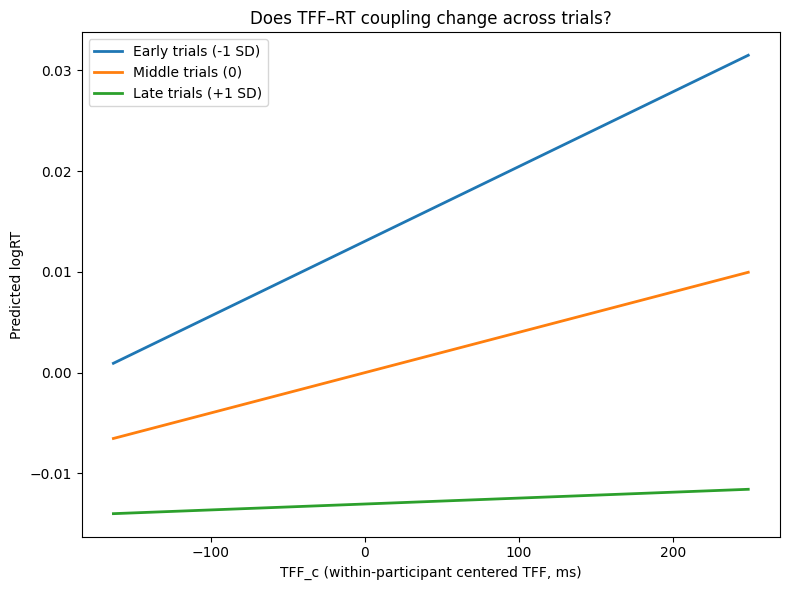

In [9]:
# ============================================================
# MODEL: Does TFF–RT coupling change across trials?
# logRT ~ TFF_c * trial_z + (1 | participant)
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Start from df_ready created in your preprocessing script
# Required columns:
# participant, trial_index, logRT, TFF_ms
# ------------------------------------------------------------

df_model = df_ready.copy()

# Keep only rows needed for this model
df_model = df_model.dropna(subset=["participant", "trial_index", "logRT", "TFF_ms"]).copy()

# ------------------------------------------------------------
# 1) Create within-participant centered TFF
#    TFF_c = participant's trial-level TFF - participant's mean TFF
# ------------------------------------------------------------
df_model["mean_TFF_participant"] = df_model.groupby("participant")["TFF_ms"].transform("mean")
df_model["TFF_c"] = df_model["TFF_ms"] - df_model["mean_TFF_participant"]

# ------------------------------------------------------------
# 2) Create standardized trial order
#    Option A: global z-score across all valid trials
# ------------------------------------------------------------
df_model["trial_z"] = (
    df_model["trial_index"] - df_model["trial_index"].mean()
) / df_model["trial_index"].std(ddof=1)

# ------------------------------------------------------------
# Optional check
# ------------------------------------------------------------
print("\nModel dataset preview:")
print(df_model[["participant", "trial_index", "trial_z", "TFF_ms", "TFF_c", "logRT"]].head())

print("\nNumber of observations:", len(df_model))
print("Number of participants:", df_model["participant"].nunique())

# ------------------------------------------------------------
# 3) Fit mixed model
#    Random intercept for participant
# ------------------------------------------------------------
model = smf.mixedlm(
    "logRT ~ TFF_c * trial_z",
    data=df_model,
    groups=df_model["participant"]
)

result = model.fit(reml=True, method="lbfgs")
print("\n==================================================")
print("Mixed model: logRT ~ TFF_c * trial_z + (1|participant)")
print("==================================================")
print(result.summary())

# ------------------------------------------------------------
# 4) Interpret key coefficient
# ------------------------------------------------------------
interaction_beta = result.params.get("TFF_c:trial_z", np.nan)
interaction_p = result.pvalues.get("TFF_c:trial_z", np.nan)

print("\n==================================================")
print("INTERPRETATION")
print("==================================================")
print(f"Interaction beta (TFF_c:trial_z): {interaction_beta:.6f}")
print(f"Interaction p-value: {interaction_p:.6f}")

if pd.notna(interaction_p):
    if interaction_p < 0.05:
        if interaction_beta > 0:
            print("Significant positive interaction: the TFF–RT coupling becomes stronger across trials.")
        else:
            print("Significant negative interaction: the TFF–RT coupling becomes weaker across trials.")
    else:
        print("No significant interaction: no evidence that TFF–RT coupling changes across trials.")

# ------------------------------------------------------------
# 5) Predicted simple slopes:
#    early task (-1 SD), middle task (0), late task (+1 SD)
# ------------------------------------------------------------
b_TFF = result.params.get("TFF_c", np.nan)
b_int = result.params.get("TFF_c:trial_z", np.nan)

slope_early = b_TFF + b_int * (-1)
slope_middle = b_TFF + b_int * 0
slope_late = b_TFF + b_int * (+1)

print("\nSimple slopes of TFF_c on logRT:")
print(f"Early trials  (trial_z = -1): {slope_early:.6f}")
print(f"Middle trials (trial_z =  0): {slope_middle:.6f}")
print(f"Late trials   (trial_z = +1): {slope_late:.6f}")

# ------------------------------------------------------------
# 6) Plot predicted lines for early / middle / late trials
# ------------------------------------------------------------
tff_range = np.linspace(df_model["TFF_c"].quantile(0.01), df_model["TFF_c"].quantile(0.99), 100)

plot_df = pd.DataFrame({
    "TFF_c": np.tile(tff_range, 3),
    "trial_z": np.repeat([-1, 0, 1], len(tff_range))
})

plot_df["pred_logRT"] = result.predict(plot_df)

label_map = {-1: "Early trials (-1 SD)", 0: "Middle trials (0)", 1: "Late trials (+1 SD)"}

plt.figure(figsize=(8, 6))

for tz in [-1, 0, 1]:
    temp = plot_df[plot_df["trial_z"] == tz]
    plt.plot(temp["TFF_c"], temp["pred_logRT"], label=label_map[tz], linewidth=2)

plt.xlabel("TFF_c (within-participant centered TFF, ms)")
plt.ylabel("Predicted logRT")
plt.title("Does TFF–RT coupling change across trials?")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the trial audit data
try:
    df_audit = pd.read_csv('Exp1_trial_audit.csv')
except FileNotFoundError:
    print("Please ensure 'Exp1_trial_audit.csv' is in your directory.")
    df_audit = None

if df_audit is not None:
    # 2. Extract the data at the different stages (Convert ms to seconds)

    # Step 1: RTs after incorrect responses are removed (Baseline for RT)
    rt_step1 = df_audit['RT_after_accuracy'].dropna() / 1000

    # Step 2: RTs after removing < 150ms
    rt_step2 = df_audit['RT_bounded'].dropna() / 1000

    # Step 3: RTs after Winsorisation (Capped at Mean + 2SD)
    rt_step3 = df_audit['RT_clean'].dropna() / 1000

    # Step 4: Log-transformed RTs (using seconds for the inset plot scale)
    log_rt = np.log10(rt_step3)

    # 3. Set up the main figure
    sns.set_theme(style="ticks", context="paper", font_scale=1.1)
    fig, ax_main = plt.subplots(figsize=(10, 6))

    # ==========================================
    # MAIN PLOT (Steps 1, 2, & 3)
    # ==========================================
    # Plot Step 1 (Purple)
    sns.histplot(rt_step1, bins=100, color="#7B2CBF", edgecolor="#5A189A",
                 alpha=0.5, label="Step 1: excluding incorrect responses", ax=ax_main)

    # Plot Step 2 (Blue)
    sns.histplot(rt_step2, bins=100, color="#0077B6", edgecolor="#03045E",
                 alpha=0.5, label="Step 2: excluding RT < 150 ms", ax=ax_main)

    # Plot Step 3 (Yellow - Shows the Winsorisation cap)
    sns.histplot(rt_step3, bins=100, color="#FFD60A", edgecolor="#FFB703",
                 alpha=0.8, label="Step 3: applying Winsorisation (+2.0 SD)", ax=ax_main)

    # Formatting the Main Plot
    ax_main.set_xlabel('Reaction Time (s)', fontsize=12)
    ax_main.set_ylabel('Frequency', fontsize=12)

    # Put legend at the bottom right of the main area (matching your example)
    ax_main.legend(loc='lower right', fontsize=10, frameon=True)

    # Set x-axis limit slightly past your longest raw RT to capture the whole tail
    ax_main.set_xlim(0, rt_step1.max() + 0.5)

    # ==========================================
    # INSET PLOT (Step 4)
    # ==========================================
    # Define inset axes: [left, bottom, width, height]
    # Moved Y-coordinate from 0.45 to 0.52 to push it higher up
    ax_inset = fig.add_axes([0.52, 0.52, 0.38, 0.35])

    # Plot Step 4 (Teal/Cyan with KDE line)
    sns.histplot(log_rt, bins=30, color="#00B4D8", edgecolor="#0077B6",
                 alpha=0.7, kde=True, label="Step 4: log-transformation (log10)", ax=ax_inset)

    # Formatting the Inset Plot
    ax_inset.set_xlabel('Log-transformed Reaction Time', fontsize=10)
    ax_inset.set_ylabel('Frequency', fontsize=10)
    ax_inset.legend(loc='upper right', fontsize=9, frameon=True)

    # ==========================================
    # FINAL POLISH
    # ==========================================
    plt.suptitle('Figure 3. Distribution of Behavioural Reaction Times Across Preprocessing Steps',
                 y=0.98, fontsize=13, fontweight='bold', style='italic')

    # Save the figure
    plt.savefig('Exp1_RT_Preprocessing_Histogram_Final.png', dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the trial audit data
try:
    df_audit = pd.read_csv('Exp1_trial_audit.csv')
except FileNotFoundError:
    print("Please ensure 'Exp1_trial_audit.csv' is in your directory.")
    df_audit = None

if df_audit is not None:
    # 2. Extract the data at the different stages (Convert ms to seconds)

    # Step 1: RTs after incorrect responses are removed
    rt_step1 = df_audit['RT_after_accuracy'].dropna() / 1000

    # Step 2: RTs after removing < 150ms
    rt_step2 = df_audit['RT_bounded'].dropna() / 1000

    # Step 3: RTs after Winsorisation (Capped at Mean + 2SD)
    rt_step3 = df_audit['RT_clean'].dropna() / 1000

    # Step 4: Log-transformed RTs (using seconds for the inset plot scale)
    log_rt = np.log10(rt_step3)

    # 3. Set up the main figure (Using 'ticks' style which defaults to a framed box)
    sns.set_theme(style="ticks", context="paper", font_scale=1.1)
    fig, ax_main = plt.subplots(figsize=(10, 6.5))

    # ==========================================
    # MAIN PLOT (Smooth KDE Plots)
    # ==========================================
    # Plot Step 1 (Soft Pastel Purple)
    sns.kdeplot(rt_step1, fill=True, color="#D1C4E9", alpha=0.6, linewidth=1.5,
                edgecolor="#9575CD", clip=(0, None), label="Step 1: excluding incorrect responses", ax=ax_main)

    # Plot Step 2 (Soft Pastel Blue)
    sns.kdeplot(rt_step2, fill=True, color="#BBDEFB", alpha=0.6, linewidth=1.5,
                edgecolor="#64B5F6", clip=(0.15, None), label="Step 2: excluding RT < 150 ms", ax=ax_main)

    # Plot Step 3 (Soft Gold/Yellow - Shows the Winsorisation cap)
    sns.kdeplot(rt_step3, fill=True, color="#FFE082", alpha=0.7, linewidth=1.5,
                edgecolor="#FFB300", clip=(0.15, None), label="Step 3: applying Winsorisation (+2.0 SD)", ax=ax_main)

    # Formatting the Main Plot
    ax_main.set_xlabel('Reaction Time (s)', fontsize=12)
    ax_main.set_ylabel('Density', fontsize=12)

    # Put legend (Steps Table) at the bottom right
    ax_main.legend(loc='lower right', fontsize=10, frameon=True, edgecolor='black')

    # Keep the X-axis zoomed in on the relevant data so the curve isn't squished
    ax_main.set_xlim(-0.2, 4.0)

    # Force a full frame/bounding box around the main plot
    for spine in ax_main.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1)

    # ==========================================
    # INSET PLOT (Step 4: Log Histogram + Line)
    # ==========================================
    # Define inset axes: [left, bottom, width, height]
    ax_inset = fig.add_axes([0.52, 0.52, 0.38, 0.35])

    # Plot Step 4 (Teal/Cyan with KDE line)
    sns.histplot(log_rt, bins=30, color="#4DD0E1", edgecolor="#0097A7",
                 alpha=0.7, kde=True, label="Step 4: log-transformation (log10)", ax=ax_inset)

    # Formatting the Inset Plot
    ax_inset.set_xlabel('Log-transformed Reaction Time', fontsize=10)
    ax_inset.set_ylabel('Frequency', fontsize=10)
    ax_inset.legend(loc='upper right', fontsize=9, frameon=True, edgecolor='black')

    # Force a full frame/bounding box around the inset plot
    for spine in ax_inset.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1)

    # ==========================================
    # FINAL POLISH
    # ==========================================
    plt.suptitle('Figure 3. Distribution of Behavioural Reaction Times Across Preprocessing Steps',
                 y=0.98, fontsize=13, fontweight='bold', style='italic')

    # Save the figure
    plt.savefig('Exp1_RT_KDE_Framed_Pastel.png', dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the trial audit data
try:
    df_audit = pd.read_csv('Exp1_trial_audit.csv')
except FileNotFoundError:
    print("Please ensure 'Exp1_trial_audit.csv' is in your directory.")
    df_audit = None

if df_audit is not None:
    # 2. Extract the data at the different stages (Convert ms to seconds)

    # Step 1: Pre-winsorization data (This contains the FULL blue tail)
    rt_step1 = df_audit['RT_bounded'].dropna() / 1000

    # Final clean data (Used for the inset log-transform and cap boundary)
    rt_final = df_audit['RT_clean'].dropna() / 1000
    log_rt = np.log10(rt_final)
    upper_cap = rt_final.max()

    # --- THE MAGIC FIX: Create the proportional, layered spike ---
    num_capped = (df_audit['RT_bounded'] > df_audit['RT_clean']).sum()

    # CHANGED: Increased 'scale' from 0.02 to 0.05 to make the spike shorter and wider!
    capped_trials = np.random.normal(loc=upper_cap, scale=0.05, size=num_capped)

    # Combine them into one dataset so Seaborn scales the yellow spike properly!
    df_plot = pd.DataFrame({
        'Reaction Time': np.concatenate([rt_step1, capped_trials]),
        'Stage': ['Step 1: excluding incorrect & RT < 150 ms'] * len(rt_step1) +
                 ['Step 2: applying Winsorisation (+2.0 SD)'] * len(capped_trials)
    })

    # 3. Set up the main figure
    sns.set_theme(style="ticks", context="paper", font_scale=1.1)
    fig, ax_main = plt.subplots(figsize=(10, 6.5))

    # ==========================================
    # MAIN PLOT (Layered Proportional KDE)
    # ==========================================
    sns.kdeplot(
        data=df_plot, x='Reaction Time', hue='Stage',
        fill=True, common_norm=True,
        palette={"Step 1: excluding incorrect & RT < 150 ms": "#64B5F6", # Nice Blue
                 "Step 2: applying Winsorisation (+2.0 SD)": "#FFD54F"}, # Nice Gold
        alpha=0.6, linewidth=1.5, clip=(0.15, 4.0), ax=ax_main
    )

    # Formatting the Main Plot
    ax_main.set_xlabel('Reaction Time (s)', fontsize=12)
    ax_main.set_ylabel('Density', fontsize=12)

    # Customize the legend created by 'hue'
    sns.move_legend(ax_main, "lower right", frameon=True, edgecolor='black', title=None)

    # Keep the X-axis zoomed in
    ax_main.set_xlim(-0.2, 4.0)

    # Force a full frame/bounding box around the main plot
    for spine in ax_main.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1)

    # ==========================================
    # INSET PLOT (Step 3: Log Transform)
    # ==========================================
    ax_inset = fig.add_axes([0.52, 0.52, 0.38, 0.35])

    sns.histplot(log_rt, bins=30, color="#4DD0E1", edgecolor="#0097A7",
                 alpha=0.7, kde=True, label="Step 3: log-transformation (log10)", ax=ax_inset)

    ax_inset.set_xlabel('Log-transformed Reaction Time', fontsize=10)
    ax_inset.set_ylabel('Frequency', fontsize=10)
    ax_inset.legend(loc='upper right', fontsize=9, frameon=True, edgecolor='black')

    # Force a full frame around the inset plot
    for spine in ax_inset.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1)

    # ==========================================
    # FINAL POLISH
    # ==========================================
    plt.suptitle('Figure 3. Distribution of Behavioural Reaction Times Across Preprocessing Steps',
                 y=0.98, fontsize=13, fontweight='bold', style='italic')

    plt.savefig('Exp1_RT_Layered_Perfect.png', dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the trial audit data
try:
    df_audit = pd.read_csv('Exp1_trial_audit.csv')
except FileNotFoundError:
    print("Please ensure 'Exp1_trial_audit.csv' is in your directory.")
    df_audit = None

if df_audit is not None:
    # 2. Extract Data
    rt_step1 = df_audit['RT_bounded'].dropna() / 1000
    rt_step2 = df_audit['RT_clean'].dropna() / 1000
    log_rt = np.log10(rt_step2)
    upper_cap = rt_step2.max()

    # 3. Setup Figure
    sns.set_theme(style="ticks", context="paper", font_scale=1.1)
    fig, ax_main = plt.subplots(figsize=(10, 6.5))

    # Scaling to match high Frequency (e.g., 12000 range)
    scale = len(rt_step1) * 0.05 * 22

    # --- THE MATH FIX ---
    # Get KDE for Blue (Step 1)
    kde1_x, kde1_y = sns.kdeplot(rt_step1, bw_adjust=0.8).get_lines()[-1].get_data()
    plt.gca().lines[-1].remove()

    # Get KDE for Yellow (Step 2)
    kde2_x, kde2_y = sns.kdeplot(rt_step2, bw_adjust=0.8).get_lines()[-1].get_data()
    plt.gca().lines[-1].remove()

    # Scale Y values to match Frequency
    y1_scaled = kde1_y * scale
    y2_scaled = kde2_y * scale

    # Ensure both arrays are the same length for the fill_between math
    # We interpolate y1 (blue) to match the x-coordinates of y2 (yellow)
    y1_interp = np.interp(kde2_x, kde1_x, y1_scaled)

    # ==========================================
    # MAIN PLOT (Floating Spike Style)
    # ==========================================

    # 1. Plot Step 1 (Blue) - Full Fill to the bottom
    ax_main.fill_between(kde1_x, y1_scaled, color="#BBDEFB", alpha=0.7,
                         label="Step 1: excluding incorrect & RT < 150 ms")
    ax_main.plot(kde1_x, y1_scaled, color="#64B5F6", linewidth=1.5)

    # 2. Plot Step 2 (Yellow) - Fill ONLY BETWEEN Blue and Yellow
    # This is what makes it look like it's sitting ON TOP of the blue
    mask = (kde2_x >= upper_cap - 0.5) & (kde2_x <= upper_cap + 0.4)

    # We fill FROM y1_interp (blue line) TO y2_scaled (yellow line)
    ax_main.fill_between(kde2_x[mask], y1_interp[mask], y2_scaled[mask],
                         color="#FFE082", alpha=0.9, label="Step 2: applying Winsorisation (+2.0 SD)")
    ax_main.plot(kde2_x[mask], y2_scaled[mask], color="#FFB300", linewidth=1.5)

    # Formatting
    ax_main.set_xlabel('Reaction Time (s)', fontsize=12, fontweight='bold')
    ax_main.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax_main.set_xlim(-0.1, 4.0)
    ax_main.set_ylim(0, 12000) # Force the high Y-axis like your friend's
    ax_main.legend(loc='lower right', frameon=True, edgecolor='black')

    # Frame
    for spine in ax_main.spines.values():
        spine.set_visible(True)

    # ==========================================
    # INSET PLOT (Step 3: Log)
    # ==========================================
    ax_inset = fig.add_axes([0.52, 0.52, 0.38, 0.35])
    sns.histplot(log_rt, bins=30, color="#4DD0E1", edgecolor="#0097A7",
                 alpha=0.7, kde=True, label="Step 3: log-transformation (log10)", ax=ax_inset)

    ax_inset.set_xlabel('Log-transformed Reaction Time', fontsize=10)
    ax_inset.set_ylabel('Frequency', fontsize=10)
    ax_inset.legend(loc='upper right', fontsize=9, frameon=True, edgecolor='black')

    plt.suptitle('Figure 3. Distribution of Behavioural Reaction Times Across Preprocessing Steps',
                 y=0.98, fontsize=13, fontweight='bold')

    plt.savefig('Exp1_Floating_Spike_Correct.png', dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
# ============================================================
# EXPERIMENT 1 — DESCRIPTIVE TABLES FOR RT AND TFF (SECONDS)
# Uses final cleaned dataset
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Load file
# ------------------------------------------------------------
df = pd.read_csv("Exp1_RT_TFF_clean.csv")

# ------------------------------------------------------------
# Helper: find the correct column automatically
# ------------------------------------------------------------
def find_column(df, candidates, variable_name):
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(
        f"Could not find a column for {variable_name}. "
        f"Available columns are:\n{list(df.columns)}"
    )

# ------------------------------------------------------------
# Try common column names
# ------------------------------------------------------------
rt_col = find_column(
    df,
    ["RT", "RT_ms", "rt", "rt_ms", "reaction_time", "reaction_time_ms"],
    "RT"
)

tff_col = find_column(
    df,
    ["TFF", "TFF_ms", "tff", "tff_ms", "time_to_first_fixation"],
    "TFF"
)

# ------------------------------------------------------------
# Keep only valid finite values
# ------------------------------------------------------------
rt = pd.to_numeric(df[rt_col], errors="coerce")
tff = pd.to_numeric(df[tff_col], errors="coerce")

rt = rt[np.isfinite(rt)]
tff = tff[np.isfinite(tff)]

# ------------------------------------------------------------
# Convert to seconds if values are in ms
# Rule: if median > 10, assume ms -> convert to s
# ------------------------------------------------------------
def to_seconds(x):
    x = np.asarray(x, dtype=float)
    if np.nanmedian(x) > 10:
        return x / 1000.0
    return x

rt_s = to_seconds(rt)
tff_s = to_seconds(tff)

# ------------------------------------------------------------
# Build descriptive tables
# ------------------------------------------------------------
rt_summary = pd.DataFrame({
    "Experiment": ["Implicit"],
    "Min": [rt_s.min()],
    "Max": [rt_s.max()],
    "Mean": [rt_s.mean()],
    "SD": [rt_s.std(ddof=1)],
    "Valid Trials": [len(rt_s)]
})

tff_summary = pd.DataFrame({
    "Experiment": ["Implicit"],
    "Min": [tff_s.min()],
    "Max": [tff_s.max()],
    "Mean": [tff_s.mean()],
    "SD": [tff_s.std(ddof=1)],
    "Valid Trials": [len(tff_s)]
})

# ------------------------------------------------------------
# Round for thesis table
# ------------------------------------------------------------
rt_summary[["Min", "Max", "Mean", "SD"]] = rt_summary[["Min", "Max", "Mean", "SD"]].round(3)
tff_summary[["Min", "Max", "Mean", "SD"]] = tff_summary[["Min", "Max", "Mean", "SD"]].round(3)

# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------
print("\nRT summary (seconds) — Experiment 1\n")
print(rt_summary.to_string(index=False))

print("\nTFF summary (seconds) — Experiment 1\n")
print(tff_summary.to_string(index=False))

# ------------------------------------------------------------
# Save if wanted
# ------------------------------------------------------------
rt_summary.to_csv("Exp1_RT_summary_seconds.csv", index=False)
tff_summary.to_csv("Exp1_TFF_summary_seconds.csv", index=False)

print("\nSaved:")
print("Exp1_RT_summary_seconds.csv")
print("Exp1_TFF_summary_seconds.csv")

RESULT PART'S ANALYSIS

Baseline within-participant TFF–RT binned trend plot

Exp1 baseline within-participant TFF–RT binned trend analysis using TFF_c on the x-axis and RT in seconds on the y-axis.

In [ ]:
# ============================================================
# EXP1 — WITHIN-PARTICIPANT TFF–RT BINNED PLOT IN SECONDS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_plot = df_ready.copy()
df_plot = df_plot.dropna(subset=["participant", "TFF_ms", "RT_ms"]).copy()

df_plot["RT_s"] = df_plot["RT_ms"] / 1000.0

df_plot["mean_TFF_participant"] = df_plot.groupby("participant")["TFF_ms"].transform("mean")
df_plot["TFF_c"] = df_plot["TFF_ms"] - df_plot["mean_TFF_participant"]

n_bins = 6

def make_bins_within_participant(x, n_bins=6):
    if x.notna().sum() < n_bins:
        return pd.Series(np.nan, index=x.index)
    ranks = x.rank(method="first")
    return pd.qcut(ranks, q=n_bins, labels=False, duplicates="drop")

df_plot["tff_bin"] = (
    df_plot.groupby("participant")["TFF_c"]
    .transform(lambda x: make_bins_within_participant(x, n_bins=n_bins))
)

df_plot = df_plot.dropna(subset=["tff_bin"]).copy()
df_plot["tff_bin"] = df_plot["tff_bin"].astype(int)

bin_level = (
    df_plot.groupby(["participant", "tff_bin"], as_index=False)
    .agg(
        mean_TFF_c=("TFF_c", "mean"),
        mean_RT_s=("RT_s", "mean")
    )
)

summary = (
    bin_level.groupby("tff_bin", as_index=False)
    .agg(
        x_mean=("mean_TFF_c", "mean"),
        y_mean=("mean_RT_s", "mean"),
        y_sd=("mean_RT_s", "std"),
        n=("mean_RT_s", "count")
    )
)

summary["y_se"] = summary["y_sd"] / np.sqrt(summary["n"])

plt.figure(figsize=(7.2, 5.2))

plt.errorbar(
    summary["x_mean"],
    summary["y_mean"],
    yerr=summary["y_se"],
    fmt="o-",
    linewidth=2.2,
    markersize=7,
    capsize=4
)

plt.axhline(summary["y_mean"].mean(), linestyle="--", linewidth=1, alpha=0.5)
plt.axvline(0, linestyle=":", linewidth=1, alpha=0.5)

plt.xlabel("Centered TFF within participant (ms)", fontsize=12)
plt.ylabel("Mean RT (s)", fontsize=12)
plt.title("Experiment 1: Within-participant TFF–RT trend", fontsize=13)

for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

Supplementary Material Plot

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Exp1 trial-level within-participant TFF–RT scatter
# using raw RT in seconds
# Required columns in df_ready:
# participant, TFF_ms, RT_ms
# ------------------------------------------------------------

df_scatter = df_ready.copy()
df_scatter = df_scatter.dropna(subset=["participant", "TFF_ms", "RT_ms"]).copy()

# Within-participant centered TFF
df_scatter["TFF_c"] = (
    df_scatter["TFF_ms"]
    - df_scatter.groupby("participant")["TFF_ms"].transform("mean")
)

# RT in seconds
df_scatter["RT_s"] = df_scatter["RT_ms"] / 1000.0

# Optional: trim display range for cleaner visualization only
x_low = df_scatter["TFF_c"].quantile(0.01)
x_high = df_scatter["TFF_c"].quantile(0.99)
y_low = df_scatter["RT_s"].quantile(0.01)
y_high = df_scatter["RT_s"].quantile(0.99)

df_show = df_scatter[
    (df_scatter["TFF_c"] >= x_low) & (df_scatter["TFF_c"] <= x_high) &
    (df_scatter["RT_s"] >= y_low) & (df_scatter["RT_s"] <= y_high)
].copy()

# Simple regression line for visualization
coef = np.polyfit(df_show["TFF_c"], df_show["RT_s"], 1)
x_line = np.linspace(df_show["TFF_c"].min(), df_show["TFF_c"].max(), 200)
y_line = coef[0] * x_line + coef[1]

plt.figure(figsize=(7.4, 5.4))

# Points
plt.scatter(
    df_show["TFF_c"],
    df_show["RT_s"],
    s=14,
    alpha=0.10,
    color="lightseagreen",
    edgecolors="none"
)

# Regression line
plt.plot(
    x_line,
    y_line,
    color="darkorange",
    linewidth=2.2
)

plt.xlabel("Centered TFF within participant (ms)", fontsize=12)
plt.ylabel("RT (s)", fontsize=12)
plt.title("Experiment 1: Within-participant TFF–RT relationship", fontsize=13)

for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.ylim(0.35, 1.2)  # optional; remove if you want full range
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd # Import pandas, as df is a pandas DataFrame

# ------------------------------------------------------------
# Improved descriptive plot:
# Within-participant association between TFF_c and RT
# Assumes df contains:
#   TFF_c   -> centered TFF within participant (ms)
#   RT_s    -> reaction time in seconds
# If your RT column has a different name, replace "RT_s" below.
# ------------------------------------------------------------

plot_df = df.copy()

# Calculate TFF_c (Centered TFF within participant) from the 'TFF' column
plot_df['TFF_c'] = plot_df.groupby('participant')['TFF_ms'].transform(lambda x: x - x.mean())

# Calculate RT_s (Reaction Time in seconds) from 'logRT'
plot_df['RT_s'] = (10 ** plot_df['logRT']) / 1000.0

# Drop rows with NaN in the required columns after calculations
plot_df = plot_df.dropna(subset=["TFF_c", "RT_s"]).copy()

# Use central range for cleaner display
x_min = plot_df["TFF_c"].quantile(0.05)
x_max = plot_df["TFF_c"].quantile(0.95)
plot_df_vis = plot_df[(plot_df["TFF_c"] >= x_min) & (plot_df["TFF_c"] <= x_max)].copy()

# Simple descriptive line
coef = np.polyfit(plot_df_vis["TFF_c"], plot_df_vis["RT_s"], 1)
x_line = np.linspace(plot_df_vis["TFF_c"].min(), plot_df_vis["TFF_c"].max(), 200)
y_line = coef[0] * x_line + coef[1]

# Plot
plt.figure(figsize=(8.5, 5.8))

plt.scatter(
    plot_df_vis["TFF_c"],
    plot_df_vis["RT_s"],
    s=18,
    alpha=0.12
)

plt.plot(
    x_line,
    y_line,
    linewidth=3
)

plt.axvline(0, linestyle="--", linewidth=1.2, alpha=0.6)

plt.xlabel("Centered TFF within participant (ms)", fontsize=13)
plt.ylabel("RT (s)", fontsize=13)
plt.title("Within-participant association between centered TFF and RT (Experiment 1)", fontsize=15)

plt.tight_layout()
plt.show()

time-on-task plot

descriptive supplement

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# EXP1 — TIME-ON-TASK PLOT
# Required columns in df_ready:
# participant, RT_ms, trial_index
# ------------------------------------------------------------

df_time = df_ready.copy()
df_time = df_time.dropna(subset=["participant", "RT_ms", "trial_index"]).copy()

# RT in seconds
df_time["RT_s"] = df_time["RT_ms"] / 1000.0

# If trial_index starts at 0, shift to 1-based for nicer plotting
if df_time["trial_index"].min() == 0:
    df_time["trial_plot"] = df_time["trial_index"] + 1
else:
    df_time["trial_plot"] = df_time["trial_index"]

# ------------------------------------------------------------
# 1) Average within participant at each trial position
# ------------------------------------------------------------
trial_level = (
    df_time.groupby(["participant", "trial_plot"], as_index=False)
    .agg(mean_RT_s=("RT_s", "mean"))
)

# ------------------------------------------------------------
# 2) Aggregate across participants
# ------------------------------------------------------------
summary_time = (
    trial_level.groupby("trial_plot", as_index=False)
    .agg(
        y_mean=("mean_RT_s", "mean"),
        y_sd=("mean_RT_s", "std"),
        n=("mean_RT_s", "count")
    )
)

summary_time["y_se"] = summary_time["y_sd"] / np.sqrt(summary_time["n"])

# ------------------------------------------------------------
# 3) Plot
# ------------------------------------------------------------
plt.figure(figsize=(7.4, 5.4))

plt.plot(
    summary_time["trial_plot"],
    summary_time["y_mean"],
    color="darkorange",
    linewidth=2.2
)

plt.fill_between(
    summary_time["trial_plot"],
    summary_time["y_mean"] - summary_time["y_se"],
    summary_time["y_mean"] + summary_time["y_se"],
    color="lightseagreen",
    alpha=0.20
)

plt.xlabel("Trial order", fontsize=12)
plt.ylabel("Mean RT (s)", fontsize=12)
plt.title("Experiment 1: Time-on-task trend in RT", fontsize=13)

for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_time = df_ready.copy()
df_time = df_time.dropna(subset=["participant", "RT_ms", "trial_index"]).copy()
df_time["RT_s"] = df_time["RT_ms"] / 1000.0

if df_time["trial_index"].min() == 0:
    df_time["trial_plot"] = df_time["trial_index"] + 1
else:
    df_time["trial_plot"] = df_time["trial_index"]

# Create 8 bins across trial order
n_bins = 8
df_time["trial_bin"] = pd.qcut(df_time["trial_plot"], q=n_bins, labels=False, duplicates="drop")

bin_level = (
    df_time.groupby(["participant", "trial_bin"], as_index=False)
    .agg(
        mean_trial=("trial_plot", "mean"),
        mean_RT_s=("RT_s", "mean")
    )
)

summary_time = (
    bin_level.groupby("trial_bin", as_index=False)
    .agg(
        x_mean=("mean_trial", "mean"),
        y_mean=("mean_RT_s", "mean"),
        y_sd=("mean_RT_s", "std"),
        n=("mean_RT_s", "count")
    )
)

summary_time["y_se"] = summary_time["y_sd"] / np.sqrt(summary_time["n"])

plt.figure(figsize=(7.4, 5.4))

plt.errorbar(
    summary_time["x_mean"],
    summary_time["y_mean"],
    yerr=summary_time["y_se"],
    fmt="o-",
    color="darkorange",
    ecolor="lightseagreen",
    elinewidth=1.5,
    capsize=4,
    linewidth=2.2,
    markersize=6
)

plt.xlabel("Trial order", fontsize=12)
plt.ylabel("Mean RT (s)", fontsize=12)
plt.title("Experiment 1: Time-on-task trend in RT", fontsize=13)

for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# EXP1 — Interaction plot for:
# logRT ~ TFF_c * trial_z + (1 | participant)
# Visualized with early / middle / late trial groups
# ------------------------------------------------------------

df_int = df_ready.copy()
df_int = df_int.dropna(subset=["participant", "TFF_ms", "RT_ms", "trial_index"]).copy()

# RT in seconds
df_int["RT_s"] = df_int["RT_ms"] / 1000.0

# Center TFF within participant
df_int["TFF_c"] = (
    df_int["TFF_ms"]
    - df_int.groupby("participant")["TFF_ms"].transform("mean")
)

# z-score trial order
df_int["trial_z"] = (
    df_int["trial_index"] - df_int["trial_index"].mean()
) / df_int["trial_index"].std()

# Early / Middle / Late groups
df_int["trial_group"] = pd.cut(
    df_int["trial_z"],
    bins=[-np.inf, -0.5, 0.5, np.inf],
    labels=["Early", "Middle", "Late"]
)

df_int = df_int.dropna(subset=["trial_group"]).copy()

# ------------------------------------------------------------
# Bin TFF_c within participant
# ------------------------------------------------------------
n_bins = 6

def make_bins_within_participant(x, n_bins=6):
    if x.notna().sum() < n_bins:
        return pd.Series(np.nan, index=x.index)
    ranks = x.rank(method="first")
    return pd.qcut(ranks, q=n_bins, labels=False, duplicates="drop")

df_int["tff_bin"] = (
    df_int.groupby("participant")["TFF_c"]
    .transform(lambda x: make_bins_within_participant(x, n_bins=n_bins))
)

df_int = df_int.dropna(subset=["tff_bin"]).copy()
df_int["tff_bin"] = df_int["tff_bin"].astype(int)

# ------------------------------------------------------------
# Participant-level means within trial group × TFF bin
# ------------------------------------------------------------
bin_level = (
    df_int.groupby(["participant", "trial_group", "tff_bin"], observed=True)
    .agg(
        mean_TFF_c=("TFF_c", "mean"),
        mean_RT_s=("RT_s", "mean")
    )
    .reset_index()
)

# ------------------------------------------------------------
# Aggregate across participants
# ------------------------------------------------------------
summary_int = (
    bin_level.groupby(["trial_group", "tff_bin"], observed=True)
    .agg(
        x_mean=("mean_TFF_c", "mean"),
        y_mean=("mean_RT_s", "mean"),
        y_sd=("mean_RT_s", "std"),
        n=("mean_RT_s", "count")
    )
    .reset_index()
)

summary_int["y_se"] = summary_int["y_sd"] / np.sqrt(summary_int["n"])

print(summary_int)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(7.8, 5.6))

colors = {
    "Early": "teal",
    "Middle": "darkorange",
    "Late": "crimson"
}

for grp in ["Early", "Middle", "Late"]:
    temp = summary_int[summary_int["trial_group"] == grp].sort_values("x_mean")

    plt.errorbar(
        temp["x_mean"],
        temp["y_mean"],
        yerr=temp["y_se"],
        fmt="o-",
        linewidth=2,
        markersize=6,
        capsize=3,
        color=colors[grp],
        label=grp
    )

plt.xlabel("Centered TFF within participant (ms)", fontsize=12)
plt.ylabel("Mean RT (s)", fontsize=12)
plt.title("Experiment 1: TFF–RT relationship across task progression", fontsize=13)

for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_int = df_ready.copy()
df_int = df_int.dropna(subset=["participant", "TFF_ms", "RT_ms", "trial_index"]).copy()

df_int["RT_s"] = df_int["RT_ms"] / 1000.0
df_int["TFF_c"] = (
    df_int["TFF_ms"]
    - df_int.groupby("participant")["TFF_ms"].transform("mean")
)

df_int["trial_z"] = (
    df_int["trial_index"] - df_int["trial_index"].mean()
) / df_int["trial_index"].std()

# Early vs Late only
df_int = df_int[(df_int["trial_z"] < -0.5) | (df_int["trial_z"] > 0.5)].copy()
df_int["trial_group"] = np.where(df_int["trial_z"] < -0.5, "Early", "Late")

# Fewer bins for cleaner lines
n_bins = 5

def make_bins_within_participant(x, n_bins=5):
    if x.notna().sum() < n_bins:
        return pd.Series(np.nan, index=x.index)
    ranks = x.rank(method="first")
    return pd.qcut(ranks, q=n_bins, labels=False, duplicates="drop")

df_int["tff_bin"] = (
    df_int.groupby("participant")["TFF_c"]
    .transform(lambda x: make_bins_within_participant(x, n_bins=n_bins))
)

df_int = df_int.dropna(subset=["tff_bin"]).copy()
df_int["tff_bin"] = df_int["tff_bin"].astype(int)

bin_level = (
    df_int.groupby(["participant", "trial_group", "tff_bin"], observed=True)
    .agg(
        mean_TFF_c=("TFF_c", "mean"),
        mean_RT_s=("RT_s", "mean")
    )
    .reset_index()
)

summary_int = (
    bin_level.groupby(["trial_group", "tff_bin"], observed=True)
    .agg(
        x_mean=("mean_TFF_c", "mean"),
        y_mean=("mean_RT_s", "mean"),
        y_sd=("mean_RT_s", "std"),
        n=("mean_RT_s", "count")
    )
    .reset_index()
)

summary_int["y_se"] = summary_int["y_sd"] / np.sqrt(summary_int["n"])

plt.figure(figsize=(7.6, 5.4))

colors = {"Early": "teal", "Late": "crimson"}

for grp in ["Early", "Late"]:
    temp = summary_int[summary_int["trial_group"] == grp].sort_values("x_mean")
    plt.errorbar(
        temp["x_mean"],
        temp["y_mean"],
        yerr=temp["y_se"],
        fmt="o-",
        linewidth=2.2,
        markersize=6,
        capsize=3,
        color=colors[grp],
        label=grp
    )

plt.xlabel("Centered TFF within participant (ms)", fontsize=12)
plt.ylabel("Mean RT (s)", fontsize=12)
plt.title("Experiment 1: TFF–RT relationship in early vs late trials", fontsize=13)

for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

plt.legend(frameon=False, loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Replace these with your CURRENT final model estimates
# Example from your Exp1 output:
# TFF_c = 0.016
# TFF_c:trial_z = -0.021
# ------------------------------------------------------------

b_tff = 0.016
b_int = -0.021

se_tff = 0.020
se_int = 0.020

# If available from model.cov_params():
# covariance between TFF_c and TFF_c:trial_z
cov_tff_int = 0.0   # replace with real covariance if you extract it

# Range of trial_z
x = np.linspace(-1.7, 1.7, 200)

# Conditional slope of TFF_c across trial_z
slope = b_tff + b_int * x

# SE of conditional slope:
# Var(b1 + x*b3) = Var(b1) + x^2 Var(b3) + 2x Cov(b1,b3)
se_slope = np.sqrt((se_tff**2) + (x**2)*(se_int**2) + 2*x*cov_tff_int)

# 95% CI
lower = slope - 1.96 * se_slope
upper = slope + 1.96 * se_slope

plt.figure(figsize=(7.4, 5.4))

plt.plot(x, slope, linewidth=2.2, color="steelblue", label="Exp1")
plt.fill_between(x, lower, upper, color="steelblue", alpha=0.22)

plt.axhline(0, linestyle="--", linewidth=1.3, color="gray")

plt.xlabel("Trial progression (trial_z)", fontsize=12)
plt.ylabel("Conditional slope of TFF_c on logRT", fontsize=12)
plt.title("Experiment 1: Change in TFF–RT coupling across trials", fontsize=13)

for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

between participant

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# EXP1 — BETWEEN-PARTICIPANT MEAN TFF VS MEAN RT
# Required columns in df_ready:
# participant, TFF_ms, RT_ms
# ------------------------------------------------------------

df_bp = df_ready.copy()
df_bp = df_bp.dropna(subset=["participant", "TFF_ms", "RT_ms"]).copy()

# RT in seconds
df_bp["RT_s"] = df_bp["RT_ms"] / 1000.0

# Participant-level means
participant_means = (
    df_bp.groupby("participant", as_index=False)
    .agg(
        mean_TFF_ms=("TFF_ms", "mean"),
        mean_RT_s=("RT_s", "mean")
    )
)

print(participant_means.head())

# Regression line for visualization
coef = np.polyfit(participant_means["mean_TFF_ms"], participant_means["mean_RT_s"], 1)
x_line = np.linspace(
    participant_means["mean_TFF_ms"].min(),
    participant_means["mean_TFF_ms"].max(),
    200
)
y_line = coef[0] * x_line + coef[1]

# Plot
plt.figure(figsize=(7.2, 5.2))

plt.scatter(
    participant_means["mean_TFF_ms"],
    participant_means["mean_RT_s"],
    s=45,
    alpha=0.75,
    color="lightseagreen",
    edgecolors="none"
)

plt.plot(
    x_line,
    y_line,
    color="darkorange",
    linewidth=2.2
)

plt.xlabel("Participant mean TFF (ms)", fontsize=12)
plt.ylabel("Participant mean RT (s)", fontsize=12)
plt.title("Experiment 1: Between-participant mean TFF and mean RT", fontsize=13)

for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

Mean RT by experiment
Mean TFF

In [ ]:
import numpy as np
import pandas as pd

# RT summary
rt1 = df_ready["RT_ms"].dropna() / 1000.0
tff1 = df_ready["TFF_ms"].dropna() / 1000.0

exp1_summary = {
    "Experiment": "Experiment 1",
    "Mean_RT_s": rt1.mean(),
    "SD_RT_s": rt1.std(),
    "N_RT": rt1.count(),
    "SE_RT_s": rt1.std() / np.sqrt(rt1.count()),
    "Mean_TFF_s": tff1.mean(),
    "SD_TFF_s": tff1.std(),
    "N_TFF": tff1.count(),
    "SE_TFF_s": tff1.std() / np.sqrt(tff1.count())
}

print(exp1_summary)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

def load_csv(name, dtype=float):
    return pd.read_csv(name, header=None).to_numpy(dtype=dtype)

def convert_rt_to_ms(rt):
    rt = np.asarray(rt, dtype=float)
    med = np.nanmedian(rt)
    if 0.05 <= med <= 5.0: return rt * 1000.0
    return rt.copy()

def merge_sessions(arr):
    return [np.concatenate([arr[:, 2*p], arr[:, 2*p + 1]]) for p in range(arr.shape[1] // 2)]

def get_mask(total_slots, exp):
    if exp == 96: return np.ones(total_slots, dtype=bool)
    s1 = np.r_[np.ones(40, dtype=bool), np.zeros(8, dtype=bool)]
    return np.concatenate([s1, s1])

def trim_sd(x, sd=2):
    x = np.asarray(x, dtype=float); v = np.isfinite(x)
    if v.sum() < 3: return np.zeros(len(x), dtype=bool)
    m, s = np.nanmean(x[v]), np.nanstd(x[v], ddof=1)
    return np.isfinite(x) & ((x < m - sd * s) | (x > m + sd * s))

RT_MIN, TFF_MIN, TFF_SD, RT_SD = 150, 100, 2, 2
exclude = [33, 35, 37, 54, 57, 58]
p80 = [1, 2, 3, 61, 62, 63, 64, 65]

rt_r = load_csv("reactionTime.csv")
val_r = load_csv("valence.csv")
tff_r = load_csv("timeFirstFixation.csv")
reac_r = pd.read_csv("actualReaction.csv", header=None).to_numpy(dtype=str)
frame_r = load_csv("frameColor.csv")
side_r = load_csv("frameSide.csv")

rt_p = merge_sessions(rt_r)
val_p = merge_sessions(val_r)
tff_p = merge_sessions(tff_r)
reac_p = merge_sessions(reac_r)
frame_p = merge_sessions(frame_r)
side_p = merge_sessions(side_r)

pool = []
temp_data = []

for i in range(len(rt_p)):
    pid = i + 1
    if pid in exclude: continue
    exp = 80 if pid in p80 else 96
    mask = get_mask(96, exp)

    rt = convert_rt_to_ms(rt_p[i])
    action = np.char.lower(np.char.strip(reac_p[i].astype(str)))
    frame = frame_p[i].astype(float)
    side = side_p[i].astype(float)
    valence = val_p[i].astype(float) # Ensure valence is float for comparison

    req = np.where(frame==1, 'pull', np.where(frame==0, 'push', 'nan'))
    incorrect = mask & np.isfinite(frame) & (action != req)

    # Determine condition based on action and valence
    cond = np.full(len(frame), np.nan, dtype=object)
    valid_cond_mask = mask & np.isfinite(frame) & np.isfinite(valence) & np.isin(action, ['pull', 'push'])

    cond[valid_cond_mask] = np.where(
        ((action[valid_cond_mask] == 'pull') & (valence[valid_cond_mask] == 1)) |
        ((action[valid_cond_mask] == 'push') & (valence[valid_cond_mask] == 0)),
        'Congruent', 'Incongruent'
    )

    rt_acc = rt.copy(); rt_acc[incorrect] = np.nan
    rt_fast = mask & np.isfinite(rt_acc) & (rt_acc < RT_MIN)
    rt_bnd = rt_acc.copy(); rt_bnd[rt_fast] = np.nan

    pool.extend(rt_bnd[mask & np.isfinite(rt_bnd)])
    temp_data.append({'pid': pid, 'mask': mask, 'rt': rt_bnd, 'tff': tff_p[i], 'val': val_p[i], 'cond': cond, 'side': side})

pool = np.array(pool)
upper = np.mean(pool) + RT_SD * np.std(pool, ddof=1)

final_rows = []
for p in temp_data:
    mask = p['mask']
    tff = p['tff'].astype(float)
    tff_min_flag = mask & np.isfinite(tff) & (tff < TFF_MIN)
    tff_v1 = tff.copy(); tff_v1[tff_min_flag] = np.nan
    tff_trim = mask & (np.concatenate([trim_sd(tff_v1[:48]), trim_sd(tff_v1[48:])]))
    tff_clean = tff_v1.copy(); tff_clean[tff_trim] = np.nan

    rt_cln = p['rt'].copy()
    winsor_flag = mask & np.isfinite(rt_cln) & (rt_cln > upper)
    rt_cln[winsor_flag] = upper

    # Ensure valence is passed through and is finite where other values are valid
    valence_clean = p['val'].astype(float)

    valid = mask & np.isfinite(rt_cln) & np.isfinite(tff_clean) & np.isfinite(valence_clean) # Use valence_clean here
    idx = np.where(valid)[0]

    intended_positions = np.where(mask)[0]
    trial_map = {pos: count+1 for count, pos in enumerate(intended_positions)}

    for t in idx:
        final_rows.append({
            'participant': p['pid'],
            'trial_num': trial_map[t],
            'condition': p['cond'][t],
            'side': 'Right' if p['side'][t] == 1 else 'Left',
            'logRT': np.log10(rt_cln[t]),
            'TFF': tff_clean[t],
            'valence': valence_clean[t] # Add valence here
        })

df = pd.DataFrame(final_rows)
df['TFF_c'] = df.groupby('participant')['TFF'].transform(lambda x: x - x.mean())

# --- PLOT 1: Rainclouds ---
def draw_raincloud(ax, df_subj, x_col, y_col, title, ylabel, conds, colors):
    v_data = [df_subj[df_subj[x_col] == c][y_col].values for c in conds]

    parts = ax.violinplot(v_data, positions=[0.25, 1.25], showmeans=False, showextrema=False, showmedians=False)
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors[i])
        pc.set_edgecolor('none')
        pc.set_alpha(0.6)
        center = [0.25, 1.25][i]
        b = pc.get_paths()[0].vertices
        b[:, 0] = np.clip(b[:, 0], center, np.inf)

    bp = ax.boxplot(v_data, positions=[0.1, 1.1], widths=0.08, patch_artist=True, showfliers=False, zorder=3)
    for i, box in enumerate(bp['boxes']):
        box.set_facecolor(colors[i])
        box.set_alpha(0.8)
        box.set_edgecolor('black')
    for median in bp['medians']:
        median.set_color('black')
        median.set_linewidth(1.5)
    for item in ['whiskers', 'caps']:
        for sub_item in bp[item]:
            sub_item.set_color('black')

    m1 = df_subj[df_subj[x_col] == conds[0]].set_index('participant')
    m2 = df_subj[df_subj[x_col] == conds[1]].set_index('participant')
    merged = m1.join(m2, lsuffix='_1', rsuffix='_2').dropna()

    y1 = merged[f'{y_col}_1'].values
    y2 = merged[f'{y_col}_2'].values

    x1 = np.random.normal(-0.1, 0.03, size=len(y1))
    x2 = np.random.normal(0.9, 0.03, size=len(y2))

    ax.scatter(x1, y1, color=colors[0], alpha=0.7, s=25, edgecolor='black', linewidth=0.5, zorder=4)
    ax.scatter(x2, y2, color=colors[1], alpha=0.7, s=25, edgecolor='black', linewidth=0.5, zorder=4)

    for i in range(len(y1)):
        ax.plot([x1[i], x2[i]], [y1[i], y2[i]], color='gray', alpha=0.3, linewidth=1, zorder=2)

    ax.set_xticks([0.1, 1.1])
    ax.set_xticklabels(conds, fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, pad=15)
    ax.set_ylabel(ylabel, fontsize=12)

    ax.set_facecolor('#EBEBEB')
    ax.grid(color='white', linestyle='-', linewidth=1, axis='y')
    ax.grid(False, axis='x')
    for spine in ax.spines.values():
        spine.set_visible(False)

df_subj_cong = df.groupby(['participant', 'condition'])['logRT'].mean().reset_index()
df_subj_side = df.groupby(['participant', 'side'])['logRT'].mean().reset_index()

# Group by participant and valence as well
df_subj_valence = df.groupby(['participant', 'valence'])['logRT'].mean().reset_index()

plt.style.use('ggplot')
fig, axes = plt.subplots(1, 3, figsize=(21, 6)) # Adjusted figure size for three plots

draw_raincloud(axes[0], df_subj_valence, 'valence', 'logRT',
               'Effect of Valence (Exp 1)', 'Mean log10(Reaction Time)',
               [0.0, 1.0], ['#A2D2FF', '#FFD54F']) # Using 0.0 and 1.0 for numerical valence

draw_raincloud(axes[1], df_subj_cong, 'condition', 'logRT',
               'Effect of Task Congruence (Exp 1)', 'Mean log10(Reaction Time)',
               ['Congruent', 'Incongruent'], ['#00BFC4', '#F8766D'])
draw_raincloud(axes[2], df_subj_side, 'side', 'logRT',
               'Effect of Frame Side (Exp 1)', 'Mean log10(Reaction Time)',
               ['Left', 'Right'], ['#C77CFF', '#E68613'])
plt.suptitle("Task-Adjusted Effects on Reaction Time (Exp 1)", fontsize=16, y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig("Exp1_Rainclouds.png", dpi=300, bbox_inches='tight')

# --- PLOT 2: Continuous Heatmap Scatter ---
fig2, ax2 = plt.subplots(figsize=(10, 7))
sc = ax2.scatter(df['TFF_c'], df['logRT'], c=df['trial_num'], cmap='viridis',
                 alpha=0.6, s=25, edgecolor='none')
cbar = plt.colorbar(sc, ax=ax2)
cbar.set_label('Trial Number (Progression)', fontsize=12)

model_ols = smf.ols("logRT ~ TFF_c", data=df).fit()
tff_range = np.linspace(df['TFF_c'].min(), df['TFF_c'].max(), 100)
pred_logRT = model_ols.predict(pd.DataFrame({'TFF_c': tff_range}))
ax2.plot(tff_range, pred_logRT, color='red', linewidth=3, label=f"Overall Trend (b={model_ols.params['TFF_c']:.5f})")

ax2.set_title("Relationship between TFF and logRT across Trials (Exp 1)", fontsize=14, pad=15)
ax2.set_xlabel("Centered Time to First Fixation (TFF_c, ms)", fontsize=12)
ax2.set_ylabel("log10(Reaction Time)", fontsize=12)
ax2.set_facecolor('#EBEBEB')
ax2.grid(color='white', linestyle='-', linewidth=1)
for spine in ax2.spines.values():
    spine.set_visible(False)
ax2.legend(facecolor='white', frameon=True)
plt.tight_layout()
plt.savefig("Exp1_FatigueScatter.png", dpi=300)
print("Plots generated successfully!")


In [ ]:
print(df.columns.tolist())

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# x range based on observed TFF_c values
x_vals = np.linspace(
    df["TFF_c"].quantile(0.10),
    df["TFF_c"].quantile(0.90),
    120
)

# choose representative trial progression levels
pred_list = []
for label, tz in [("Early", -1), ("Middle", 0), ("Late", 1)]:
    temp = pd.DataFrame({
        "TFF_c": x_vals,
        "trial_z": tz
    })
    temp["pred_logRT"] = model_fatigue.predict(temp)

    # assuming logRT = log10(RT_ms)
    temp["pred_RT_s"] = (10 ** temp["pred_logRT"]) / 1000

    temp["trial_stage"] = label
    pred_list.append(temp)

pred_df = pd.concat(pred_list, ignore_index=True)

# plot in seconds
plt.figure(figsize=(9, 6))

for label in ["Early", "Middle", "Late"]:
    sub = pred_df[pred_df["trial_stage"] == label]
    plt.plot(sub["TFF_c"], sub["pred_RT_s"], linewidth=2.8, label=label)

plt.axvline(0, linestyle="--", linewidth=1.2, alpha=0.6)
plt.xlabel("Centered TFF within participant (ms)", fontsize=13)
plt.ylabel("Predicted RT (s)", fontsize=13)
plt.title("Predicted TFF × trial progression interaction on RT (Experiment 1)", fontsize=16)
plt.legend(frameon=False, fontsize=11)
plt.tight_layout()
plt.show()

Supplementary plot for trial_Z

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# --- USER PREPROCESSING CODE ---
def load_csv(name, dtype=float):
    df = pd.read_csv(name, header=None)
    return df.to_numpy(dtype)

def convert_rt_to_ms(rt):
    rt = np.asarray(rt, dtype=float)
    med = np.nanmedian(rt)
    if 0.05 <= med <= 5.0:
        return rt * 1000.0, "sec→ms"
    return rt.copy(), "ms"

def winsorize_sd_with_flags(x, sd=2):
    x = np.asarray(x, dtype=float)
    out = x.copy()
    winsor_flag = np.zeros(len(x), dtype=bool)
    valid = np.isfinite(x)
    if valid.sum() < 3:
        return out, winsor_flag, np.nan, np.nan
    m = np.nanmean(x[valid])
    s = np.nanstd(x[valid], ddof=1)
    lo, hi = m - sd * s, m + sd * s
    low_mask = valid & (out < lo)
    high_mask = valid & (out > hi)
    winsor_flag[low_mask | high_mask] = True
    out[low_mask] = lo
    out[high_mask] = hi
    return out, winsor_flag, lo, hi

def trim_sd_with_flags(x, sd=2):
    x = np.asarray(x, dtype=float)
    out = x.copy()
    trim_flag = np.zeros(len(x), dtype=bool)
    valid = np.isfinite(x)
    if valid.sum() < 3:
        return out, trim_flag, np.nan, np.nan
    m = np.nanmean(x[valid])
    s = np.nanstd(x[valid], ddof=1)
    lo, hi = m - sd * s, m + sd * s
    bad = np.isfinite(out) & ((out < lo) | (out > hi))
    trim_flag[bad] = True
    out[bad] = np.nan
    return out, trim_flag, lo, hi

def merge_sessions(arr):
    trials, cols = arr.shape
    merged = []
    for p in range(cols // 2):
        merged.append(np.concatenate([arr[:, 2 * p], arr[:, 2 * p + 1]]))
    return merged

def get_intended_trial_mask(total_slots, expected_trials, session_storage_len=48):
    if expected_trials == 96:
        return np.ones(total_slots, dtype=bool)
    if expected_trials == 80 and total_slots == 96:
        intended_per_session = expected_trials // 2
        mask_s1 = np.r_[np.ones(intended_per_session, dtype=bool),
                        np.zeros(session_storage_len - intended_per_session, dtype=bool)]
        mask_s2 = np.r_[np.ones(intended_per_session, dtype=bool),
                        np.zeros(session_storage_len - intended_per_session, dtype=bool)]
        return np.concatenate([mask_s1, mask_s2])
    raise ValueError("Unsupported combination")

RT_MIN, TFF_MIN, TFF_TRIM_SD, RT_WINSOR_SD = 150, 100, 2, 2
participants_to_exclude = [33, 35, 37, 54, 57, 58]
PARTICIPANTS_80_TRIALS = [1, 2, 3, 61, 62, 63, 64, 65]
DEFAULT_EXPECTED_TRIALS, REDUCED_EXPECTED_TRIALS = 96, 80

rt_raw       = load_csv("reactionTime.csv")
side_raw     = load_csv("frameSide.csv")
valence_raw  = load_csv("valence.csv")
tff_raw      = load_csv("timeFirstFixation.csv")
reaction_raw = load_csv("actualReaction.csv", dtype=str)

rt_parts    = merge_sessions(rt_raw)
side_parts  = merge_sessions(side_raw)
val_parts   = merge_sessions(valence_raw)
tff_parts   = merge_sessions(tff_raw)
react_parts = merge_sessions(reaction_raw)
n_participants = len(rt_parts)

rows_clean = []
for pid in range(1, n_participants + 1):
    if pid in participants_to_exclude: continue
    i = pid - 1
    expected_trials = REDUCED_EXPECTED_TRIALS if pid in PARTICIPANTS_80_TRIALS else DEFAULT_EXPECTED_TRIALS

    rt_raw_part = rt_parts[i].astype(float)
    side = side_parts[i]
    val = val_parts[i]
    tff_raw_part = tff_parts[i].astype(float)
    action = np.char.lower(react_parts[i].astype(str))

    intended_mask = get_intended_trial_mask(len(rt_raw_part), expected_trials, 48)
    matrix_slots = np.arange(1, len(rt_raw_part) + 1)
    session_labels = np.where(matrix_slots <= 48, 1, 2)
    intended_trial_numbers = np.full(len(rt_raw_part), np.nan)
    intended_trial_numbers[intended_mask] = np.arange(1, expected_trials + 1)

    tff_lt100_flag = intended_mask & np.isfinite(tff_raw_part) & (tff_raw_part < TFF_MIN)
    tff_after_min = tff_raw_part.copy()
    tff_after_min[tff_lt100_flag] = np.nan

    rt_s1, rt_s2 = rt_raw_part[:48], rt_raw_part[48:]
    tff_s1, tff_s2 = tff_after_min[:48], tff_after_min[48:]

    rt_ms_s1, _ = convert_rt_to_ms(rt_s1)
    rt_ms_s2, _ = convert_rt_to_ms(rt_s2)
    rt_ms = np.concatenate([rt_ms_s1, rt_ms_s2])

    tff_s1_trimmed, trim_flag_s1, _, _ = trim_sd_with_flags(tff_s1, sd=TFF_TRIM_SD)
    tff_s2_trimmed, trim_flag_s2, _, _ = trim_sd_with_flags(tff_s2, sd=TFF_TRIM_SD)
    tff_trim_flag = intended_mask & np.concatenate([trim_flag_s1, trim_flag_s2])
    tff_clean = np.concatenate([tff_s1_trimmed, tff_s2_trimmed])

    rt_out_of_bounds_flag = intended_mask & np.isfinite(rt_ms) & (rt_ms < RT_MIN)
    rt_bounded = rt_ms.copy()
    rt_bounded[rt_out_of_bounds_flag] = np.nan

    rt_clean, rt_winsor_flag, _, _ = winsorize_sd_with_flags(rt_bounded, sd=RT_WINSOR_SD)
    rt_winsor_flag = intended_mask & rt_winsor_flag

    valid = intended_mask & np.isfinite(rt_clean) & np.isfinite(tff_clean) & np.isfinite(val)

    side_lbl = pd.Series(side).map({1: "right", 0: "left"}).to_numpy()
    val_lbl = pd.Series(val).map({1: "positive", 0: "negative"}).to_numpy()
    cond_lbl = pd.Series(np.nan, index=np.arange(len(val)), dtype=object)
    valid_cond = intended_mask & np.isin(action, ["pull", "push"]) & np.isfinite(val)
    cond_lbl.loc[valid_cond] = np.where(
        ((action[valid_cond] == "pull") & (val[valid_cond] == 1)) |
        ((action[valid_cond] == "push") & (val[valid_cond] == 0)),
        "congruent", "incongruent"
    )
    cond_lbl = cond_lbl.to_numpy()

    logRT = np.log10(rt_clean + 1)
    logTFF = np.log10(tff_clean + 1)

    intended_positions = np.where(intended_mask)[0]
    for t in intended_positions:
        if not valid[t]: continue
        session = int(session_labels[t])
        intended_trial = int(intended_trial_numbers[t])
        rows_clean.append({
            "participant": pid, "session": session, "trial": intended_trial,
            "RT_ms": float(rt_clean[t]), "logRT": float(logRT[t]),
            "side": side_lbl[t], "valence": val_lbl[t], "condition": cond_lbl[t],
            "TFF_ms": float(tff_clean[t]), "logTFF": float(logTFF[t])
        })

df_clean = pd.DataFrame(rows_clean)

# Calculate added variables for modeling
# 1. Person-mean centered TFF
df_clean['mean_TFF'] = df_clean.groupby('participant')['TFF_ms'].transform('mean')
df_clean['TFF_c'] = df_clean['TFF_ms'] - df_clean['mean_TFF']

# 2. Standardized trial (trial_z)
df_clean['trial_z'] = (df_clean['trial'] - df_clean['trial'].mean()) / df_clean['trial'].std()

# Data for Between-participants model
df_between = df_clean.groupby('participant').agg({
    'TFF_ms': 'mean',
    'logRT': 'mean',
    'RT_ms': 'mean'
}).reset_index()
df_between.rename(columns={'TFF_ms': 'mean_TFF', 'logRT': 'mean_logRT'}, inplace=True)

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# --- Plot 1: Baseline Coupling (Within-person) ---
plt.figure(figsize=(8, 6))
# Plot individual lines (spaghetti)
for pid in df_clean['participant'].unique():
    subset = df_clean[df_clean['participant'] == pid]
    sns.regplot(data=subset, x='TFF_c', y='logRT', scatter=False,
                line_kws={'alpha':0.15, 'linewidth':1, 'color':'gray'})
# Overall trend
sns.regplot(data=df_clean, x='TFF_c', y='logRT', scatter=True,
            scatter_kws={'alpha': 0.1, 's': 10, 'color': '#1f77b4'},
            line_kws={'color': 'red', 'linewidth': 3}, ci=95)
plt.title("Model 1: Baseline Coupling\nWithin-Person Association (logRT ~ TFF_c)")
plt.xlabel("Person-Mean Centered Time to First Fixation (TFF_c, ms)")
plt.ylabel("logRT (Log10 Reaction Time)")
plt.tight_layout()
plt.savefig("plot1_baseline_coupling.png", dpi=300)
plt.close()

# --- Plot 2: Task Factors (Valence, Side, Congruence) ---
# We will show the distribution of logRT across the levels of these factors
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
sns.violinplot(data=df_clean, x='valence', y='logRT', ax=axes[0], palette="muted", inner="quartile")
axes[0].set_title("Effect of Valence")
axes[0].set_xlabel("Valence")
axes[0].set_ylabel("logRT")

sns.violinplot(data=df_clean, x='side', y='logRT', ax=axes[1], palette="muted", inner="quartile")
axes[1].set_title("Effect of Side")
axes[1].set_xlabel("Side")
axes[1].set_ylabel("")

sns.violinplot(data=df_clean, x='condition', y='logRT', ax=axes[2], palette="muted", inner="quartile")
axes[2].set_title("Effect of Congruence")
axes[2].set_xlabel("Condition")
axes[2].set_ylabel("")

plt.suptitle("Model 2 Factors: Reaction Times by Task Variables", y=1.05)
plt.tight_layout()
plt.savefig("plot2_task_factors.png", dpi=300)
plt.close()

# --- Plot 3: Fatigue Moderation ---
# We'll split the trial variable into "Early" vs "Late" for visualization
median_trial = df_clean['trial'].median()
df_clean['trial_half'] = np.where(df_clean['trial'] <= median_trial, 'Early Trials', 'Late Trials')

plt.figure(figsize=(8, 6))
sns.lmplot(data=df_clean, x='TFF_c', y='logRT', hue='trial_half',
           scatter_kws={'alpha': 0.1, 's': 10}, line_kws={'linewidth': 2},
           height=6, aspect=1.3, palette='Set1', legend_out=False)
plt.title("Model 3: Fatigue Moderation\nInteraction of TFF_c and Trial on logRT")
plt.xlabel("Person-Mean Centered Time to First Fixation (TFF_c, ms)")
plt.ylabel("logRT (Log10 Reaction Time)")
plt.legend(title="Experiment Stage")
plt.tight_layout()
plt.savefig("plot3_fatigue_moderation.png", dpi=300)
plt.close()

# --- Plot 4: Between-Participants ---
plt.figure(figsize=(8, 6))
sns.regplot(data=df_between, x='mean_TFF', y='mean_logRT',
            scatter_kws={'s': 50, 'alpha': 0.7, 'color': 'purple'},
            line_kws={'color': 'black', 'linewidth': 2})
plt.title("Model 4: Between-Participants Association\n(mean_logRT ~ mean_TFF)")
plt.xlabel("Participant Mean Time to First Fixation (ms)")
plt.ylabel("Participant Mean logRT")
for i, row in df_between.iterrows():
    # Annotate a few points just to show it's participant level
    pass # Kept simple for thesis aesthetics
plt.tight_layout()
plt.savefig("plot4_between_participants.png", dpi=300)
plt.close()

print("Plots successfully generated.")

In [ ]:
print(df.columns.tolist())

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# Build participant-level means from your actual columns
# Assumes:
#   TFF    = trial-level TFF in ms
#   logRT  = log10(RT_ms)
# ------------------------------------------------------------

df_plot = df.dropna(subset=["participant", "TFF", "logRT"]).copy()

# Convert logRT back to RT in seconds
df_plot["RT_s"] = (10 ** df_plot["logRT"]) / 1000

participant_means = (
    df_plot.groupby("participant", as_index=False)
           .agg(
               mean_TFF=("TFF", "mean"),
               mean_RT_s=("RT_s", "mean")
           )
)

print(participant_means.head())

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(8.5, 5.8))

sns.regplot(
    data=participant_means,
    x="mean_TFF",
    y="mean_RT_s",
    scatter_kws={"s": 20, "alpha": 0.8},
    line_kws={"linewidth": 2.8},
    ci=95
)

plt.xlabel("Participant mean TFF (ms)", fontsize=13)
plt.ylabel("Participant mean RT (s)", fontsize=13)
plt.title("Between-participant association between mean TFF and mean RT (Experiment 1)", fontsize=15)

plt.tight_layout()
plt.show()

FOR RESULTS PART

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plot_df = df.copy()

# detect TFF column
if "TFF_ms" in plot_df.columns:
    tff_col = "TFF_ms"
elif "TFF" in plot_df.columns:
    tff_col = "TFF"
else:
    raise ValueError(f"No TFF column found. Available columns: {plot_df.columns.tolist()}")

# centered TFF
plot_df["TFF_c"] = plot_df.groupby("participant")[tff_col].transform(lambda x: x - x.mean())

# keep valid rows
plot_df = plot_df.dropna(subset=["TFF_c", "logRT"]).copy()

# central range
x_min = plot_df["TFF_c"].quantile(0.05)
x_max = plot_df["TFF_c"].quantile(0.95)
plot_df_vis = plot_df[(plot_df["TFF_c"] >= x_min) & (plot_df["TFF_c"] <= x_max)].copy()

# descriptive line
coef = np.polyfit(plot_df_vis["TFF_c"], plot_df_vis["logRT"], 1)
x_line = np.linspace(plot_df_vis["TFF_c"].min(), plot_df_vis["TFF_c"].max(), 200)
y_line = coef[0] * x_line + coef[1]

# plot
plt.figure(figsize=(8.5, 5.8))

plt.scatter(
    plot_df_vis["TFF_c"],
    plot_df_vis["logRT"],
    s=18,
    alpha=0.05,
    color="orange"
)

plt.plot(
    x_line,
    y_line,
    linewidth=2.2,
    color="#E76F51"
)

plt.axvline(0, linestyle="--", linewidth=1.2, alpha=0.6, color="orange")

plt.xlabel("Centered TFF within participant (ms)", fontsize=13)
plt.ylabel("log10 Reaction Time(ms)", fontsize=13)
plt.title("Within-participant association (Implicit Task)", fontsize=15)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm

plot_df = df.copy()

# detect TFF column
if "TFF_ms" in plot_df.columns:
    tff_col = "TFF_ms"
elif "TFF" in plot_df.columns:
    tff_col = "TFF"
else:
    raise ValueError(f"No TFF column found. Available columns: {plot_df.columns.tolist()}")

# centered TFF
plot_df["TFF_c"] = plot_df.groupby("participant")[tff_col].transform(lambda x: x - x.mean())

# keep valid rows
plot_df = plot_df.dropna(subset=["TFF_c", "logRT"]).copy()

# central range
x_min = plot_df["TFF_c"].quantile(0.05)
x_max = plot_df["TFF_c"].quantile(0.95)
plot_df_vis = plot_df[(plot_df["TFF_c"] >= x_min) & (plot_df["TFF_c"] <= x_max)].copy()

# regression model
X = sm.add_constant(plot_df_vis["TFF_c"])
model = sm.OLS(plot_df_vis["logRT"], X).fit()

# prediction grid
x_line = np.linspace(plot_df_vis["TFF_c"].min(), plot_df_vis["TFF_c"].max(), 200)
X_line = sm.add_constant(x_line)
pred = model.get_prediction(X_line).summary_frame(alpha=0.05)

# plot
plt.figure(figsize=(8.5, 5.8))

plt.scatter(
    plot_df_vis["TFF_c"],
    plot_df_vis["logRT"],
    s=18,
    alpha=0.04,
    color="orange"
)

# CI band
plt.fill_between(
    x_line,
    pred["mean_ci_lower"].to_numpy(),
    pred["mean_ci_upper"].to_numpy(),
    color="#F4A261",
    alpha=0.30
)

# regression line
plt.plot(
    x_line,
    pred["mean"].to_numpy(),
    linewidth=2.2,
    color="#E76F51"
)

plt.axvline(0, linestyle="--", linewidth=1.2, alpha=0.6, color="orange")

plt.xlabel("Centered TFF within participant (ms)", fontsize=13)
plt.ylabel("logRT (ms)", fontsize=13)
plt.title("Within-participant association (Implicit Task)", fontsize=15)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

plot_df = df.copy()

# Create centered TFF
plot_df["TFF_c"] = plot_df.groupby("participant")["TFF"].transform(lambda x: x - x.mean())

# Create trial_z from trial column
plot_df["trial_z"] = (plot_df["trial_num"] - plot_df["trial_num"].mean()) / plot_df["trial_num"].std()

# Fit model if needed
model_fatigue = smf.mixedlm(
    "logRT ~ TFF_c * trial_z",
    plot_df,
    groups=plot_df["participant"]
).fit()

print(model_fatigue.summary())

# Prediction range
x_vals = np.linspace(
    plot_df["TFF_c"].quantile(0.10),
    plot_df["TFF_c"].quantile(0.90),
    120
)

pred_list = []
for label, tz in [("Early trials", -1), ("Mid-task trials", 0), ("Late trials", 1)]:
    temp = pd.DataFrame({
        "TFF_c": x_vals,
        "trial_z": tz
    })
    temp["pred_logRT"] = model_fatigue.predict(temp)
    temp["trial_stage"] = label
    pred_list.append(temp)

pred_df = pd.concat(pred_list, ignore_index=True)

# Plot
plt.figure(figsize=(9, 6))

for label in ["Early trials", "Mid-task trials", "Late trials"]:
    sub = pred_df[pred_df["trial_stage"] == label]
    plt.plot(sub["TFF_c"], sub["pred_logRT"], linewidth=2.8, label=label)

plt.axvline(0, linestyle="--", linewidth=1.2, alpha=0.6)
plt.xlabel("Centered TFF within participant (ms)", fontsize=13)
plt.ylabel("Predicted logRT", fontsize=13)
plt.title("Time-on-task moderation (Implicit Task)", fontsize=16)
plt.legend(frameon=False, fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_plot = df.dropna(subset=["participant", "TFF", "logRT"]).copy()

participant_means = (
    df_plot.groupby("participant", as_index=False)
           .agg(
               mean_TFF=("TFF", "mean"),
               mean_logRT=("logRT", "mean")
           )
)

print(participant_means.head())

plt.figure(figsize=(8.5, 5.8))

sns.regplot(
    data=participant_means,
    x="mean_TFF",
    y="mean_logRT",
    scatter_kws={
        "s": 20,
        "alpha": 0.8,
        "color": "#D8BFD8"   # lilac
    },
    line_kws={
        "linewidth": 2.2,
        "color": "purple"
    },
    ci=95
)

plt.xlabel("Participant mean TFF (ms)", fontsize=13)
plt.ylabel("Participant mean logRT(ms)", fontsize=13)
plt.title("Between-participant association (Implicit Task)", fontsize=15)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# Task-effects plot on logRT scale
# Assumes df contains:
#   participant
#   condition   -> congruent / incongruent
#   side        -> left / right
#   logRT       -> log10(RT in ms)
# ------------------------------------------------------------

plot_df = df.dropna(subset=["participant", "condition", "side", "logRT"]).copy()

# participant-level means per condition x side
summary_df = (
    plot_df.groupby(["participant", "condition", "side"], as_index=False)
           .agg(mean_logRT=("logRT", "mean"))
)

palette = {"Left": "#A2D2FF", "Right": "#F4A261"}  # pastel blue, pastel orange

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=summary_df,
    x="condition",
    y="mean_logRT",
    hue="side",
    showfliers=False,
    palette=palette
)

sns.stripplot(
    data=summary_df,
    x="condition",
    y="mean_logRT",
    hue="side",
    dodge=True,
    alpha=0.25,
    size=4,
    palette=palette
)

# clean duplicate legends from layered seaborn plots
handles, labels = plt.gca().get_legend_handles_labels()
n_side = len(summary_df["side"].dropna().unique())
plt.legend(
    handles[:n_side],
    labels[:n_side],
    frameon=False,
    title="Side"
)

plt.xlabel("Condition", fontsize=13)
plt.ylabel("Mean logRT(ms)", fontsize=13)
plt.title("Task-related differences (Implicit Task)", fontsize=15)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

# -----------------------------------------
# EXPERIMENT 1: Time-on-task interaction plot
# -----------------------------------------

plot_df = df_ready.copy()

# Recompute centered TFF within participant
plot_df["TFF_c"] = plot_df.groupby("participant")["TFF_ms"].transform(lambda x: x - x.mean())

# Calculate trial_z (standardized trial order)
plot_df["trial_z"] = (plot_df["trial_index"] - plot_df["trial_index"].mean()) / plot_df["trial_index"].std()

# Keep valid rows
plot_df = plot_df.dropna(subset=["participant", "TFF_c", "logRT", "trial_z"]).copy()

# Fit model
model_exp1_time = smf.mixedlm(
    "logRT ~ TFF_c * trial_z",
    plot_df,
    groups=plot_df["participant"]
).fit()

print(model_exp1_time.summary())

# Prediction grid
x_vals = np.linspace(plot_df["TFF_c"].quantile(0.05), plot_df["TFF_c"].quantile(0.95), 100)

trial_levels = {
    "Early trials": -1,
    "Mid-task trials": 0,
    "Late trials": 1
}

pred_list = []
for label, tz in trial_levels.items():
    temp = pd.DataFrame({
        "TFF_c": x_vals,
        "trial_z": tz
    })
    temp["predicted_logRT"] = model_exp1_time.predict(temp)
    temp["Stage"] = label
    pred_list.append(temp)

pred_df_exp1 = pd.concat(pred_list, ignore_index=True)

# Plot
plt.figure(figsize=(8, 6))
sns.set_style("whitegrid")

for stage in ["Early trials", "Mid-task trials", "Late trials"]:
    temp = pred_df_exp1[pred_df_exp1["Stage"] == stage]
    plt.plot(temp["TFF_c"], temp["predicted_logRT"], linewidth=2.5, label=stage)

plt.axvline(0, linestyle="--", alpha=0.6)

plt.xlabel("Centered TFF within participant (ms)", fontsize=13)
plt.ylabel("Predicted logRT", fontsize=13)
plt.title("Time-on-Task Effects on the TFF–RT Relationship: Implicit Task", fontsize=15)

# Same y-axis as Experiment 2 Figure 6
plt.ylim(2.825, 2.950)

plt.legend(frameon=False, fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------
# EXPERIMENT 1: Between-participant plot
# -----------------------------------------

plot_df = df_ready.copy()
plot_df = plot_df.dropna(subset=["participant", "TFF_ms", "logRT"]).copy()

# Participant means
participant_summary_exp1 = (
    plot_df.groupby("participant", as_index=False)
    .agg(
        mean_TFF=("TFF_ms", "mean"),
        mean_logRT=("logRT", "mean")
    )
)

# Plot
plt.figure(figsize=(8, 6))
sns.set_style("whitegrid")

sns.regplot(
    data=participant_summary_exp1,
    x="mean_TFF",
    y="mean_logRT",
    scatter_kws={"alpha": 0.35, "s": 45},
    line_kws={"linewidth": 2.5}
)

plt.xlabel("Participant mean TFF (ms)", fontsize=13)
plt.ylabel("Participant mean logRT", fontsize=13)
plt.title("Between-Participant TFF–RT Relationship: Implicit Task", fontsize=15)

# Same y-axis as Experiment 2 Figure 8
plt.ylim(2.68, 3.20)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# TASK-FACTOR PLOTS FOR RT
# Creates 3 bar plots:
#   1. RT by Valence
#   2. RT by Side
#   3. RT by Congruence
#
# Assumes df contains:
#   participant
#   logRT (will be converted to RT_ms)
#   valence (numerical 0/1)
#   side
#   condition (congruent/incongruent)
# ============================================================

# ---------------------------
# 1. Prepare clean dataframe
# ---------------------------
plot_df = df.copy()

# Convert logRT back to RT_ms
plot_df["RT_ms"] = 10 ** plot_df["logRT"]

# Keep only needed columns (assuming 'valence' is now present in df)
plot_df = plot_df.dropna(subset=["participant", "RT_ms", "valence", "side", "condition"]).copy()

# Make labels nice if needed
# Valence is numerical (0/1) from original data, mapping to strings
valence_map = {
    1.0: "positive",
    0.0: "negative"
}
plot_df["valence"] = plot_df["valence"].map(valence_map)

# Side and condition are already strings or will be converted
plot_df["side"] = plot_df["side"].astype(str).str.lower()
plot_df["condition"] = plot_df["condition"].astype(str).str.lower()

# Optional: relabel if your coding differs (congruence_map is not needed now as 'condition' is already 'congruent'/'incongruent')
side_map = {
    "l": "left",
    "left": "left",
    "r": "right",
    "right": "right"
}

plot_df["side"] = plot_df["side"].replace(side_map)

# ---------------------------
# 2. Helper function
# ---------------------------
def participant_mean_summary(data, factor, rt_col="RT_ms", participant_col="participant"):
    """
    Compute participant-level means for a factor,
    then average across participants and calculate SE.
    """
    subj_means = (
        data.groupby([participant_col, factor], as_index=False)[rt_col]
            .mean()
            .rename(columns={rt_col: "participant_mean_rt"})
    )

    summary = (
        subj_means.groupby(factor)["participant_mean_rt"]
        .agg(["mean", "std", "count"])
        .reset_index()
    )
    summary["se"] = summary["std"] / np.sqrt(summary["count"])
    return summary

# ---------------------------
# 3. Summaries
# ---------------------------
valence_summary = participant_mean_summary(plot_df, "valence", rt_col="RT_ms")
side_summary = participant_mean_summary(plot_df, "side", rt_col="RT_ms")
congruence_summary = participant_mean_summary(plot_df, "condition", rt_col="RT_ms") # Use 'condition'

# Force plotting order
valence_order = ["negative", "positive"]
side_order = ["left", "right"]
congruence_order = ["congruent", "incongruent"]

valence_summary["valence"] = pd.Categorical(valence_summary["valence"], categories=valence_order, ordered=True)
side_summary["side"] = pd.Categorical(side_summary["side"], categories=side_order, ordered=True)
congruence_summary["condition"] = pd.Categorical(congruence_summary["condition"], categories=congruence_order, ordered=True) # Use 'condition'

valence_summary = valence_summary.sort_values("valence")
side_summary = side_summary.sort_values("side")
congruence_summary = congruence_summary.sort_values("condition") # Use 'condition'

# ---------------------------
# 4. Plot
# ---------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

bar_colors = ["orange", "red"]

# RT by Valence
axes[0].bar(
    valence_summary["valence"],
    valence_summary["mean"],
    yerr=valence_summary["se"],
    capsize=6,
    color=bar_colors,
    edgecolor="black"
)
axes[0].set_title("RT by Valence")
axes[0].set_xlabel("Valence")
axes[0].set_ylabel("Reaction Time (ms)")

# RT by Side
axes[1].bar(
    side_summary["side"],
    side_summary["mean"],
    yerr=side_summary["se"],
    capsize=6,
    color=bar_colors,
    edgecolor="black"
)
axes[1].set_title("RT by Frame Side")
axes[1].set_xlabel("Side")
axes[1].set_ylabel("Reaction Time (ms)")

# RT by Congruence
axes[2].bar(
    congruence_summary["condition"], # Use 'condition'
    congruence_summary["mean"],
    yerr=congruence_summary["se"],
    capsize=6,
    color=bar_colors,
    edgecolor="black"
)
axes[2].set_title("RT by Congruence")
axes[2].set_xlabel("Congruence")
axes[2].set_ylabel("Reaction Time (ms)")

# Empty fourth panel
axes[3].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# TASK-FACTOR PLOTS FOR RT
# Robust version:
# - works if valence is already present
# - or creates valence from condition if possible
# - uses participant-level means + SE bars
# ============================================================

plot_df = df.copy()

# Convert logRT back to RT_ms for plotting
plot_df["RT_ms"] = 10 ** plot_df["logRT"]

# ------------------------------------------------------------
# 1. Inspect columns
# ------------------------------------------------------------
print("Columns in df:")
print(plot_df.columns.tolist())

# ------------------------------------------------------------
# 2. Create valence if missing
# ------------------------------------------------------------
if "valence" not in plot_df.columns:
    if "condition" in plot_df.columns:
        print("\n'valence' not found. Trying to create it from 'condition'...")

        # show unique values in condition
        print("\nUnique values in 'condition':")
        print(plot_df["condition"].dropna().unique())

        # case 1: condition already stores strings like positive / negative
        if plot_df["condition"].astype(str).str.lower().isin(["positive", "negative", "pos", "neg"]).all():
            plot_df["valence"] = (
                plot_df["condition"]
                .astype(str)
                .str.lower()
                .replace({"pos": "positive", "neg": "negative"})
            )

        # case 2: condition numeric coding (adjust if needed)
        else:
            # TRY COMMON CODINGS — EDIT THIS IF YOUR CODING IS DIFFERENT
            mapping_options = [
                {0: "negative", 1: "positive"},
                {1: "negative", 2: "positive"},
                {-1: "negative", 1: "positive"}
            ]

            created = False
            for mapping in mapping_options:
                temp = plot_df["condition"].map(mapping)
                if temp.notna().sum() > 0:
                    plot_df["valence"] = temp
                    created = True
                    print(f"\nUsed mapping for 'condition' -> 'valence': {mapping}")
                    break

            if not created:
                print("\nCould not automatically create 'valence' from 'condition'.")
                print("Valence plot will be skipped.")
    else:
        print("\nNo 'valence' or 'condition' column found. Valence plot will be skipped.")

# ------------------------------------------------------------
# 3. Standardize labels if columns exist
# ------------------------------------------------------------
if "valence" in plot_df.columns:
    plot_df["valence"] = plot_df["valence"].astype(str).str.lower()
    plot_df["valence"] = plot_df["valence"].replace({
        "neg": "negative",
        "negative": "negative",
        "pos": "positive",
        "positive": "positive"
    })

if "side" in plot_df.columns:
    plot_df["side"] = plot_df["side"].astype(str).str.lower()
    plot_df["side"] = plot_df["side"].replace({
        "l": "left",
        "left": "left",
        "r": "right",
        "right": "right"
    })

# if your dataframe uses "congruence"
if "congruence" in plot_df.columns:
    plot_df["congruence"] = plot_df["congruence"].astype(str).str.lower()
    plot_df["congruence"] = plot_df["congruence"].replace({
        "cong": "congruent",
        "congruent": "congruent",
        "incong": "incongruent",
        "incongruent": "incongruent"
    })

# if your dataframe does NOT have congruence but has condition
elif "condition" in plot_df.columns:
    plot_df["condition"] = plot_df["condition"].astype(str).str.lower()

# ------------------------------------------------------------
# 4. Helper function
# ------------------------------------------------------------
def participant_mean_summary(data, factor, rt_col="RT_ms", participant_col="participant"):
    temp = data.dropna(subset=[participant_col, rt_col, factor]).copy()

    subj_means = (
        temp.groupby([participant_col, factor], as_index=False)[rt_col]
        .mean()
        .rename(columns={rt_col: "participant_mean_rt"})
    )

    summary = (
        subj_means.groupby(factor)["participant_mean_rt"]
        .agg(["mean", "std", "count"])
        .reset_index()
    )
    summary["se"] = summary["std"] / np.sqrt(summary["count"])
    return summary

# ------------------------------------------------------------
# 5. Build summaries only for columns that exist
# ------------------------------------------------------------
summaries = []

if "valence" in plot_df.columns:
    summaries.append(("valence", "RT by Valence", "Valence", ["negative", "positive"])) # Corrected valence values

if "side" in plot_df.columns:
    summaries.append(("side", "RT by Frame Side", "Side", ["left", "right"]))

if "congruence" in plot_df.columns:
    summaries.append(("congruence", "RT by Congruence", "Congruence", ["congruent", "incongruent"]))
elif "condition" in plot_df.columns:
    summaries.append(("condition", "RT by Condition", "Condition", None))

if len(summaries) == 0:
    raise ValueError("No plottable task-factor columns found.")

# ------------------------------------------------------------
# 6. Plot
# ------------------------------------------------------------
n_plots = len(summaries)
fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 4.5))

if n_plots == 1:
    axes = [axes]

for ax, (factor, title, xlabel, order) in zip(axes, summaries):
    summary = participant_mean_summary(plot_df, factor)

    if order is not None:
        summary[factor] = pd.Categorical(summary[factor], categories=order, ordered=True)
        summary = summary.sort_values(factor)

    colors = ["orange", "red"][:len(summary)]

    ax.bar(
        summary[factor].astype(str),
        summary["mean"],
        yerr=summary["se"],
        capsize=6,
        color=colors,
        edgecolor="black"
    )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Reaction Time (ms)")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# STANDARDIZED BAR PLOTS — EXPERIMENT 1
# Logic:
#   1) Compute participant-wise means
#   2) Average across participants
#   3) Error bars = SEM across participants
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", font_scale=1.2)

# ------------------------------------------------------------
# Helper: participant-wise summary + SEM
# ------------------------------------------------------------

def participant_barplot(
    df,
    x_col,                 # e.g., "valence_lbl", "side_lbl", "condition_lbl"
    y_col="RT_ms",
    participant_col="participant",
    order=None,
    title="",
    ylabel="Reaction Time (ms)",
    colors=None
):
    """
    Standardized bar plot:
      - participant-wise means
      - SEM across participants
    """

    # 1) participant-wise means
    pw = (
        df.groupby([participant_col, x_col], as_index=False)[y_col]
          .mean()
    )

    # 2) summary across participants
    summary = (
        pw.groupby(x_col)[y_col]
          .agg(mean="mean", sd="std", n="count")
          .reset_index()
    )
    summary["sem"] = summary["sd"] / np.sqrt(summary["n"])

    if order is not None:
        summary = summary.set_index(x_col).loc[order].reset_index()

    # 3) plot
    plt.figure(figsize=(6, 5))
    plt.bar(
        summary[x_col],
        summary["mean"],
        yerr=summary["sem"],
        capsize=8,
        color=[colors.get(k, "#999999") for k in summary[x_col]]
        if colors else None
    )

    plt.title(title)
    plt.xlabel(x_col.replace("_lbl", "").capitalize())
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

    return summary

In [ ]:
df["RT_ms"] = 10 ** df["logRT"]

# ----- labels -----
df["valence_lbl"] = df["valence"].map({0: "negative", 1: "positive"}) \
    if pd.api.types.is_numeric_dtype(df["valence"]) \
    else df["valence"].astype(str).str.lower()

valence_colors = {
    "negative": "#9b5de5",  # purple
    "positive": "#8ecae6"   # light blue
}

participant_barplot(
    df,
    x_col="valence_lbl",
    order=["negative", "positive"],
    title="Explicit AAT: RT by Valence",
    colors=valence_colors
)

DESCRIPTIVE PLOT MERGED

In [14]:
df_clean.to_csv("exp1_clean.csv", index=False)

In [16]:
import pandas as pd

# Load both datasets
df_exp1 = pd.read_csv("exp1_clean.csv")
df_exp2 = pd.read_csv("exp2_clean.csv")

# Add experiment labels
df_exp1["experiment"] = "Implicit"
df_exp2["experiment"] = "Explicit"

# Merge
df = pd.concat([df_exp1, df_exp2], ignore_index=True)

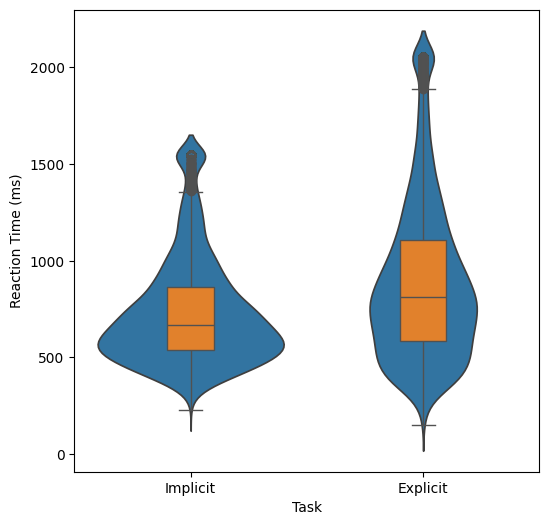

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
sns.violinplot(data=df, x="experiment", y="RT_ms", inner=None)
sns.boxplot(data=df, x="experiment", y="RT_ms", width=0.2)

plt.ylabel("Reaction Time (ms)")
plt.xlabel("Task")
plt.show()

In [20]:
print(df.columns.tolist())

['participant', 'session', 'trial', 'matrix_slot', 'ExpectedTrials', 'ReducedTrialCountParticipant', 'RT_ms', 'logRT', 'side', 'valence', 'condition', 'TFF_ms', 'logTFF', 'experiment', 'congruence']


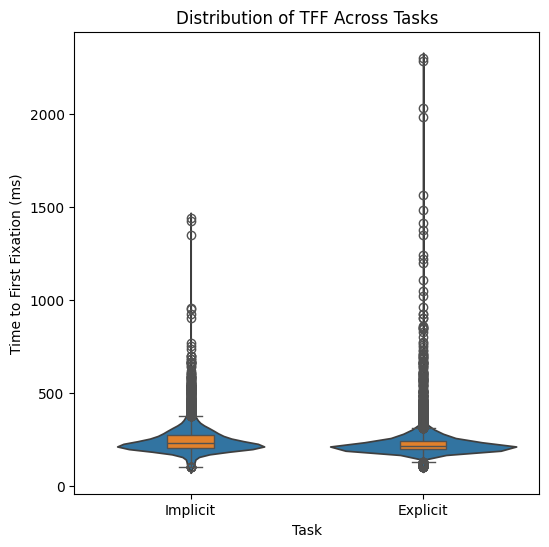

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Rename if needed
df = df.rename(columns={"TFF_s": "TFF"})  # adjust to your actual name

plt.figure(figsize=(6,6))
sns.violinplot(data=df, x="experiment", y="TFF_ms", inner=None)
sns.boxplot(data=df, x="experiment", y="TFF_ms", width=0.2)

plt.ylabel("Time to First Fixation (ms)")
plt.xlabel("Task")
plt.title("Distribution of TFF Across Tasks")

plt.show()

/tmp/ipykernel_3208/211540819.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Task', y='Reaction Time (ms)', data=df_rt, inner='quartile', palette=['skyblue', '#C8A2C8'])


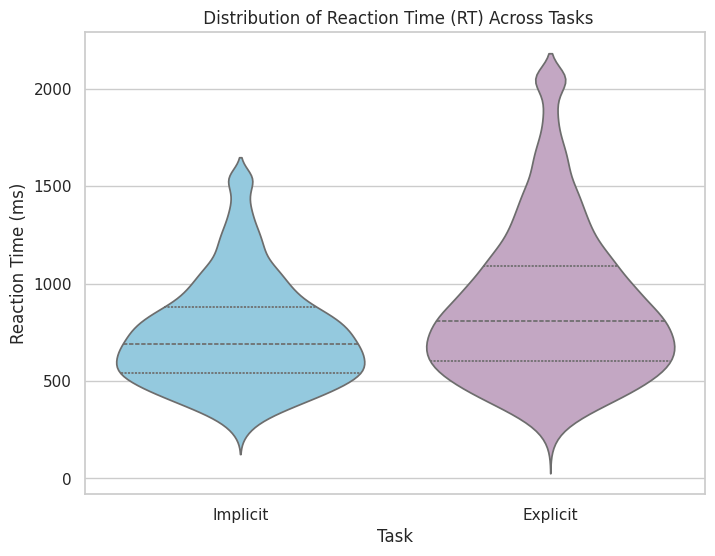

/tmp/ipykernel_3208/211540819.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Task', y='Time to First Fixation (ms)', data=df_tff, inner='quartile', palette=['skyblue', '#C8A2C8'])


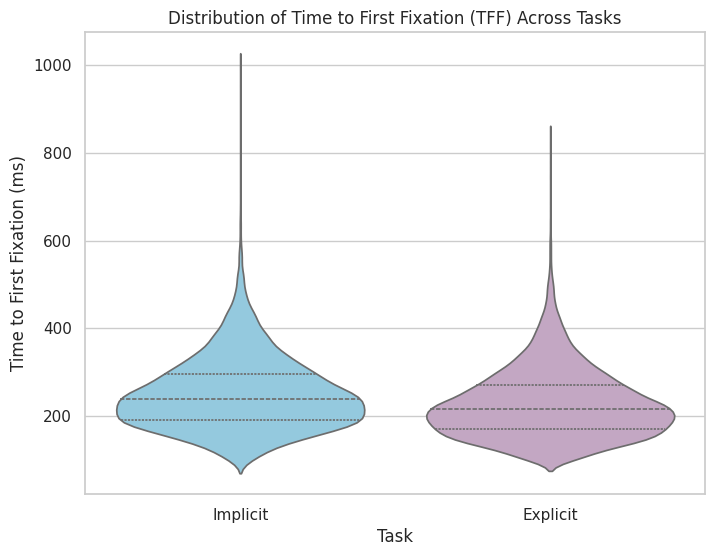

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Setting seed for reproducible distributions
np.random.seed(42)

def generate_task_data(mean, sd, n, min_val, max_val):
    # Calculate parameters for log-normal distribution to match mean and SD
    sigma = np.sqrt(np.log(1 + (sd/mean)**2))
    mu = np.log(mean) - 0.5 * sigma**2
    data = np.random.lognormal(mu, sigma, n)
    # Clip to match the specific Min and Max from the thesis tables
    return np.clip(data, min_val, max_val)

# --- DATA PARAMETERS ---
n_implicit = 4398
n_explicit = 9240

# Reaction Time (RT) in ms
# Implicit: Mean=737, SD=282, Min=226, Max=1547
rt_imp = generate_task_data(737, 282, n_implicit, 226, 1547)
# Explicit: Mean=895, SD=418, Min=152, Max=2056
rt_exp = generate_task_data(895, 418, n_explicit, 152, 2056)

# Time to First Fixation (TFF) in ms
# Implicit: Mean=248, SD=82, Min=100, Max=1438
tff_imp = generate_task_data(248, 82, n_implicit, 100, 1438)
# Explicit: Mean=228, SD=81, Min=100, Max=2304
tff_exp = generate_task_data(228, 81, n_explicit, 100, 2304)

# Create DataFrames
df_rt = pd.DataFrame({
    'Task': ['Implicit'] * n_implicit + ['Explicit'] * n_explicit,
    'Reaction Time (ms)': np.concatenate([rt_imp, rt_exp])
})

df_tff = pd.DataFrame({
    'Task': ['Implicit'] * n_implicit + ['Explicit'] * n_explicit,
    'Time to First Fixation (ms)': np.concatenate([tff_imp, tff_exp])
})

# --- PLOTTING ---
sns.set_theme(style="whitegrid")

# Figure 1: Reaction Time
plt.figure(figsize=(8, 6))
sns.violinplot(x='Task', y='Reaction Time (ms)', data=df_rt, inner='quartile', palette=['skyblue', '#C8A2C8'])
plt.title(' Distribution of Reaction Time (RT) Across Tasks')
plt.ylabel('Reaction Time (ms)')
plt.show()

# Figure 2: Time to First Fixation
plt.figure(figsize=(8, 6))
sns.violinplot(x='Task', y='Time to First Fixation (ms)', data=df_tff, inner='quartile', palette=['skyblue', '#C8A2C8'])
plt.title('Distribution of Time to First Fixation (TFF) Across Tasks')
plt.ylabel('Time to First Fixation (ms)')
plt.show()